# Behavior Analysis: LUPE-AMPS Analysis on Novel Data (Timepoint Comparison Included)

Press SHIFT + ENTER to run code

### Section 1A: USER INPUT

In [24]:
## Define project
project_name = ''

# Select group and condition, see meta.py to see how you previously defined it for your project
selected_groups = ['']
selected_conditions = ['','']

# Injury site for ALL animals
# 0 = left hindpaw (default in most LUPE studies - no flipping needed)
# 1 = right hindpaw (will swap labels 4 and 5 so "injured paw" is always label 4)
injury_site = 0

In [25]:
### Continue to Press SHIFT + ENTER to run code ###

# TIMEPOINT COMPARISON
# Define time windows (minutes) for optional timepoint analyses.
import os
import glob
import re
import numpy as np
import pandas as pd
from scipy.stats import mode
from scipy.ndimage import label
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings

warnings.filterwarnings("ignore")

# Recording parameters
sampling_rate = 60   # Original recording fps
target_fps = 20      # Downsampled fps for state model
# recording_length_minutes will be inferred automatically after loading data
bin_length = 5       # Bin length for statistics (minutes), set to 0 for no binning

# Minimum frames for a behavior to be considered "real" (100ms at 60fps = 6 frames)
min_frames_true_positive = 6

# --- Timepoint comparison inputs (defined in MINUTES) ---
use_timepoint_comparison = True
time_ranges_min = []   # list of (start_min, end_min) tuples
time_labels = []       # list of strings

if use_timepoint_comparison:
    print("\n=== TIMEPOINT COMPARISON SETUP ===")
    print("Format: start-end (minutes), e.g., 0-10")
    print("Type 'q' (or press Enter) to cancel.\n")

    raw = input("How many time windows do you want to compare? (e.g., 2): ").strip()
    if raw == "" or raw.lower() in {"q", "quit", "exit"}:
        use_timepoint_comparison = False
        print("Timepoint comparison cancelled.")
    else:
        try:
            num_timepoints = int(raw)
        except ValueError:
            raise ValueError("Please enter an integer number of time windows (or 'q' to cancel).")

        if num_timepoints < 1:
            raise ValueError("You must define at least one time window.")

        for i in range(num_timepoints):
            while True:
                s = input(f"Enter time window {i+1} (start-end), or 'q' to cancel: ").strip()

                if s == "" or s.lower() in {"q", "quit", "exit"}:
                    use_timepoint_comparison = False
                    time_ranges_min = []
                    time_labels = []
                    print("Timepoint comparison cancelled.")
                    break

                m = re.fullmatch(r"\s*(\d+)\s*-\s*(\d+)\s*", s)
                if not m:
                    print("Invalid format. Use start-end like 0-10, or 'q' to cancel.")
                    continue

                start_min = int(m.group(1))
                end_min = int(m.group(2))

                if start_min < 0:
                    print("Invalid window: start must be ≥ 0.")
                    continue
                if end_min <= start_min:
                    print("Invalid window: end must be > start.")
                    continue

                # Do NOT clip against any assumed recording length here.
                # We will clip after we infer true length from data.
                time_ranges_min.append((start_min, end_min))
                time_labels.append(f"{start_min}-{end_min} min")
                break

            if not use_timepoint_comparison:
                break

        if use_timepoint_comparison:
            print("\nTime windows requested (will be validated after data load):")
            for lbl, rng in zip(time_labels, time_ranges_min):
                print(f"  • {lbl} → {rng}")
else:
    print("Timepoint comparison disabled.")


=== TIMEPOINT COMPARISON SETUP ===
Format: start-end (minutes), e.g., 0-10
Type 'q' (or press Enter) to cancel.

Time windows defined:
  • 0-10 min → (0, 10)
  • 11-30 min → (11, 30)


### Section 1B: LOAD CONFIGURATION

In [26]:
# Paths / model inputs
base_data_dir = f"../processed_dataset/{project_name}/figures/behaviors_csv_raw-classification/frames"
output_base_dir = f"../processed_dataset/{project_name}/figures/behaviors_LUPE-AMPS_timepoint"

model_path = "../model/panpainmodel30.mat"
pca_model_path = "../model/pain_scale_params.mat"

behaviors = ["Still", "Walking", "Rearing", "Grooming", "LeftLick", "RightLick"]
states = ["State 1", "State 2", "State 3", "State 4", "State 5", "State 6"]

state_categories = {
    1: "Pain Suppressed",
    2: "Non-pain State",
    3: "Pain Enhanced",
    4: "Pain Enhanced",
    5: "Non-pain State",
    6: "Non-pain State",
}

# Derived parameters (placeholders — will be inferred AFTER loading data)
n_behaviors = 6
original_length = None          # true frames will be set after reading CSVs
downsampled_length = None       # set after original_length is known
recording_length_minutes = None # set after original_length is known
n_bins = None                   # set after original_length is known

# Window parameters for transition matrices (these are independent of recording length)
window_length_sec = 30
window_slide_sec = 10
window_size = int(target_fps * window_length_sec)
window_slide = int(target_fps * window_slide_sec)

print("Configuration loaded!")
print(f"Project: {project_name}")
print(f"Groups: {selected_groups}")
print(f"Conditions: {selected_conditions}")
print(f"Original frames: {original_length}, Downsampled: {downsampled_length}")
print(f"Bin length (min): {bin_length}")
if use_timepoint_comparison:
    print(f"Requested time windows: {time_labels}")

Configuration loaded!
Project: project_Wisc_OpioidTGFSaline
Groups: ['Formalin_Combined']
Conditions: ['SalineVeh', 'TGF']
Original frames: 108000, Downsampled: 36000


### Section 2: DATA LOADING AND BEHAVIOR STATISTICS

Found 19 files in Formalin_Combined/SalineVeh
Found 19 files in Formalin_Combined/TGF

Loaded 38 animals, 108000 frames each

Calculating behavior statistics...
Behavior statistics calculated for 38 animals
Behavior statistics exported to: ../processed_dataset/project_Wisc_OpioidTGFSaline/figures/behaviors_LUPE-AMPS/Section2_BehaviorStats
Timepoint behavior comparison saved to: ../processed_dataset/project_Wisc_OpioidTGFSaline/figures/behaviors_LUPE-AMPS/Timepoint_Comparison


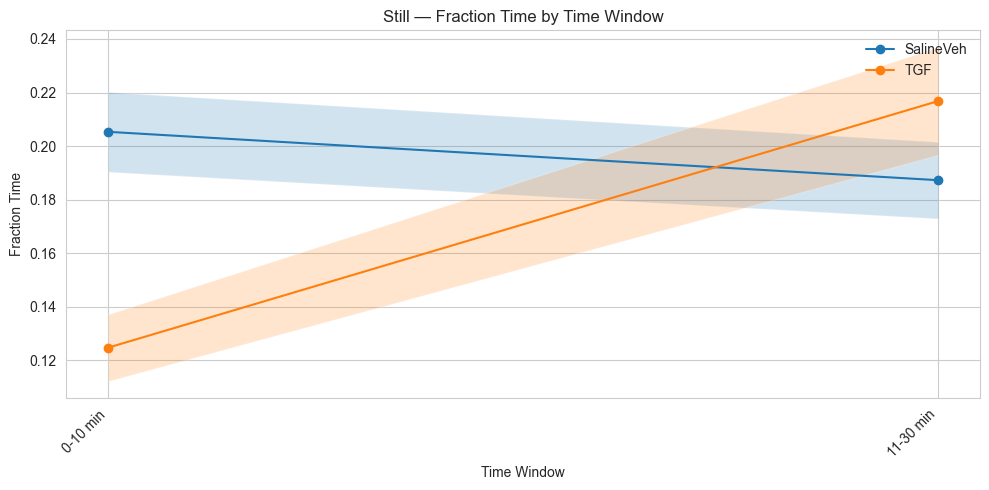

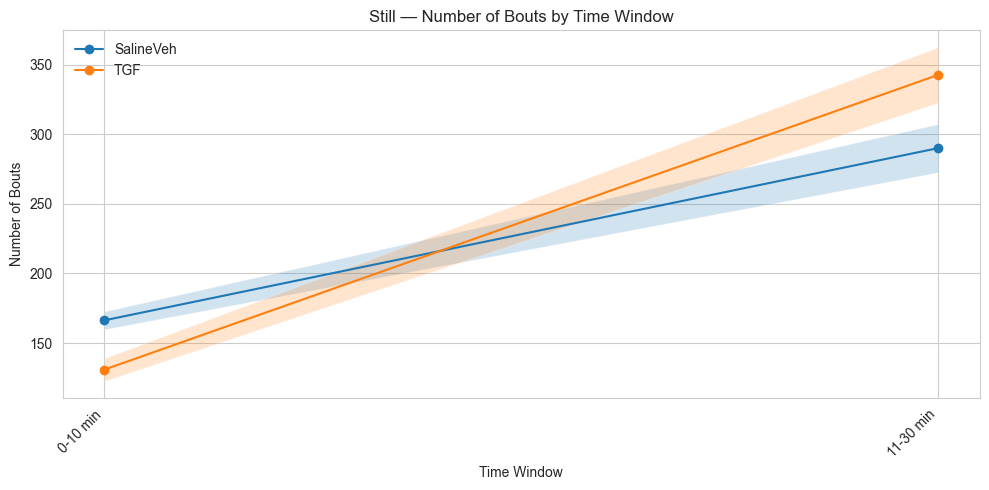

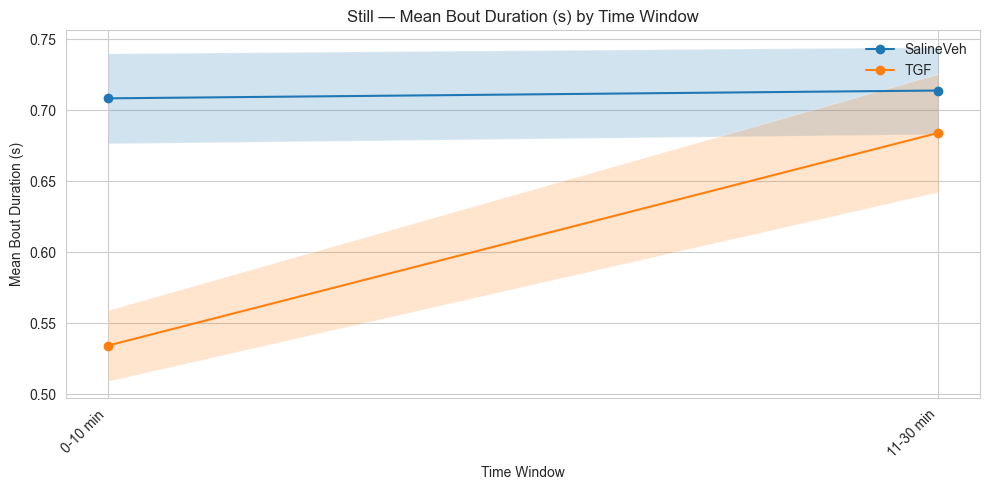

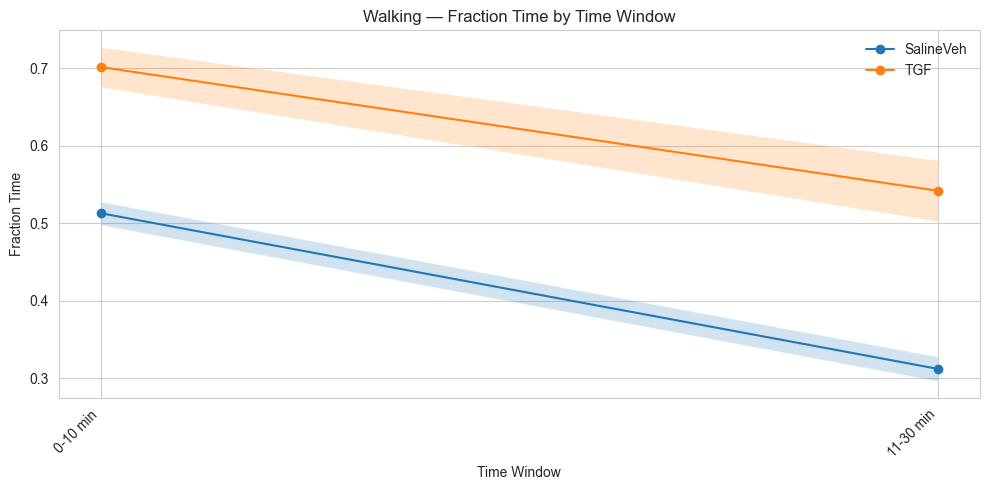

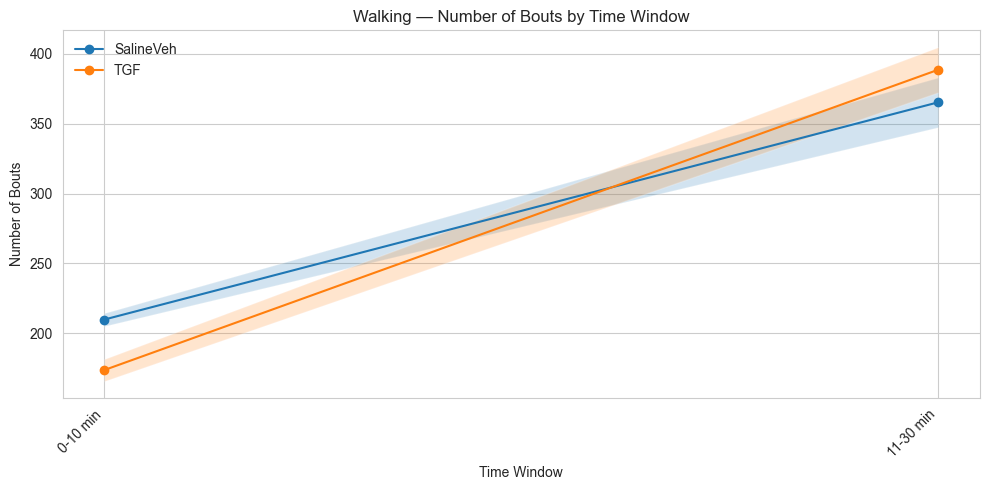

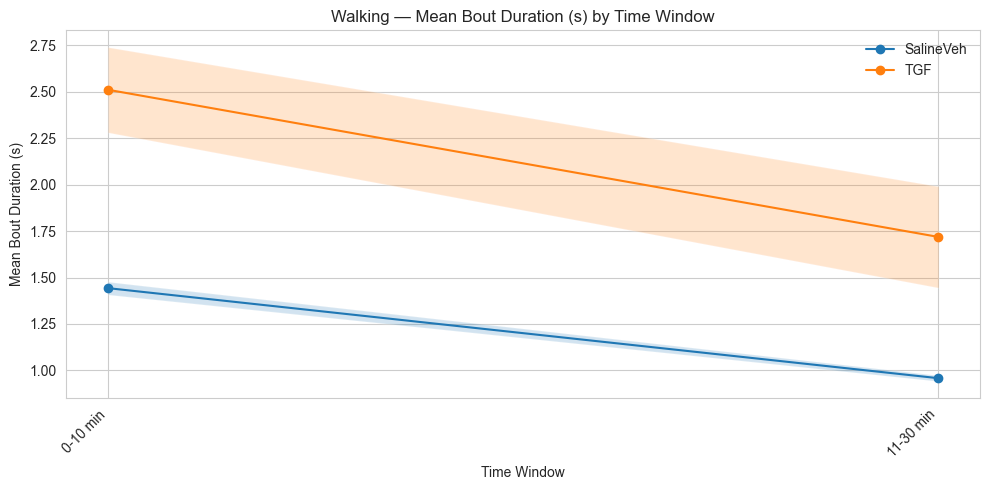

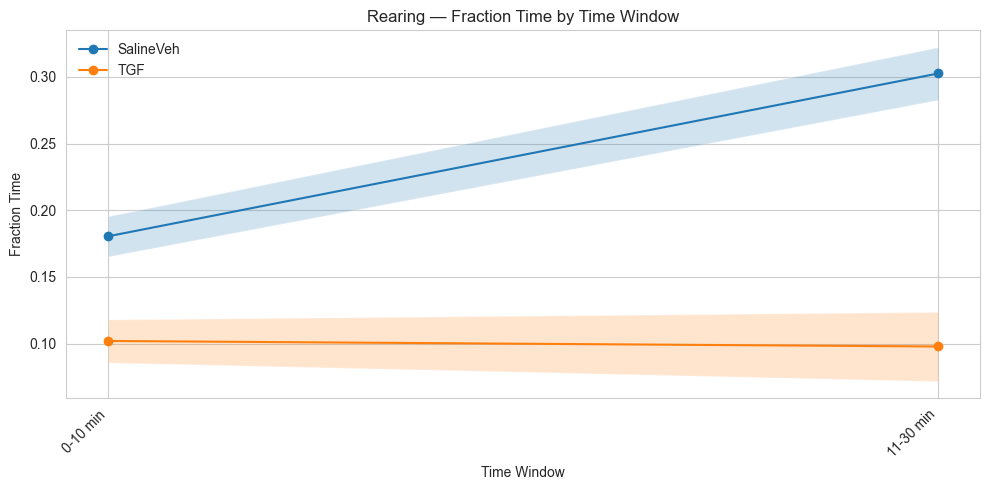

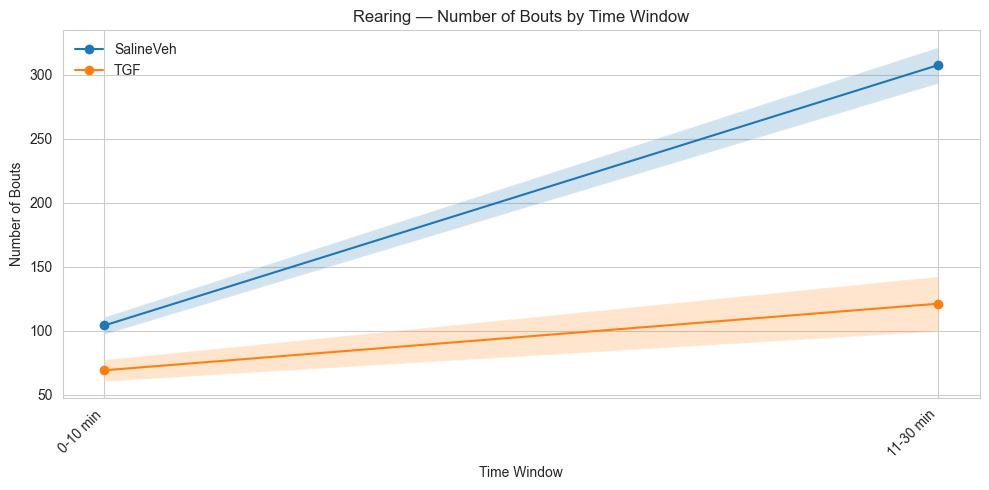

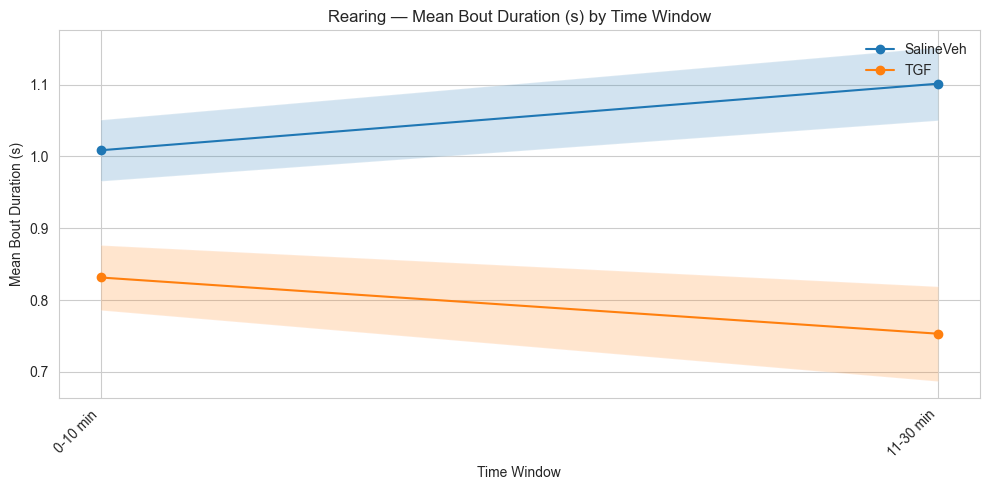

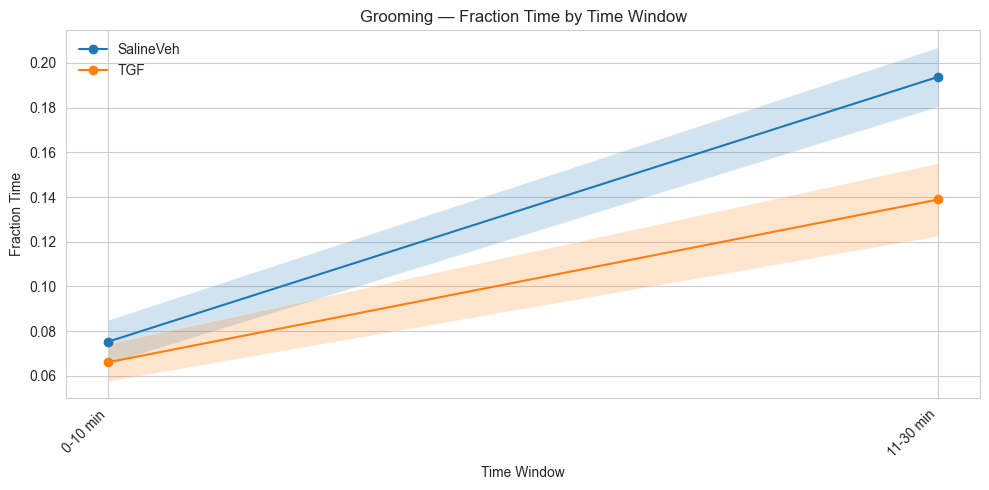

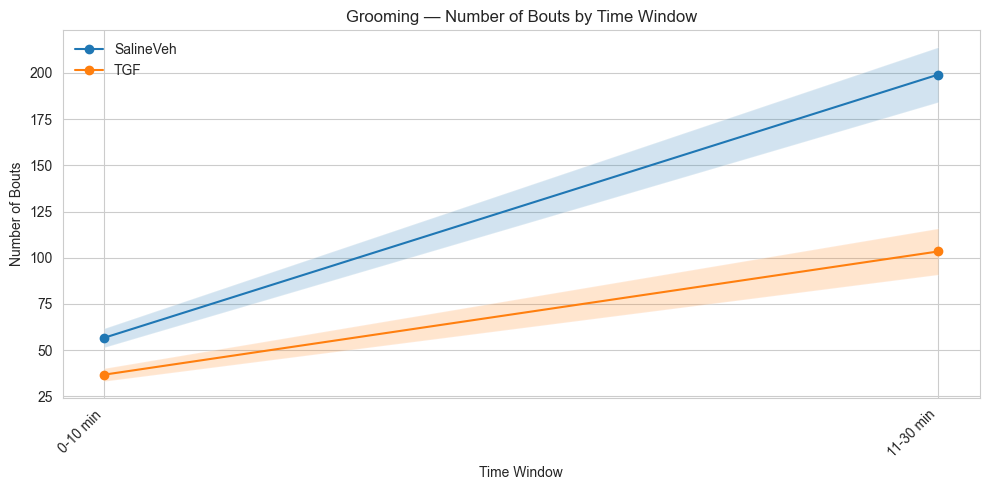

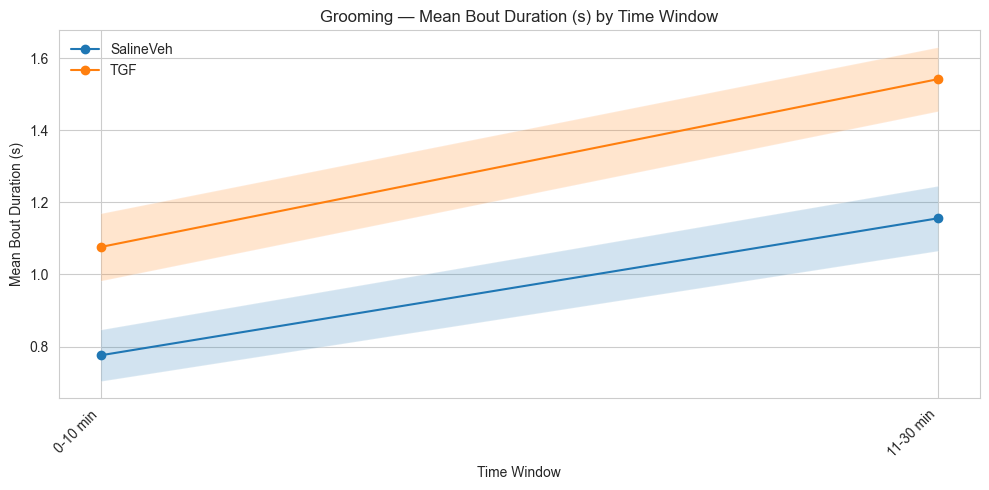

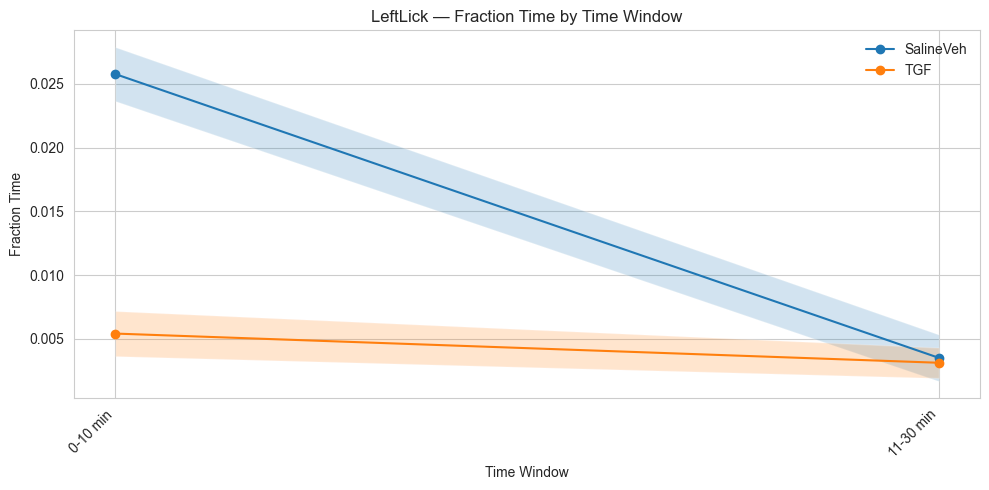

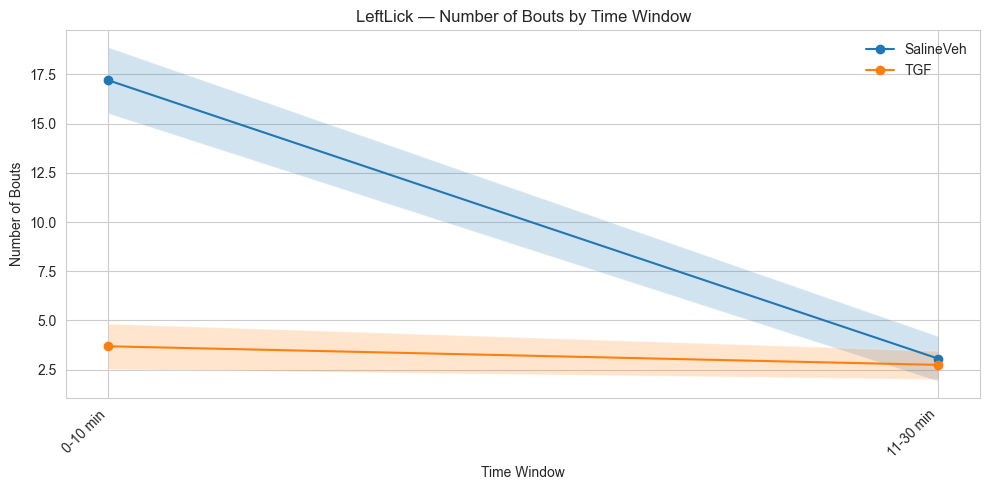

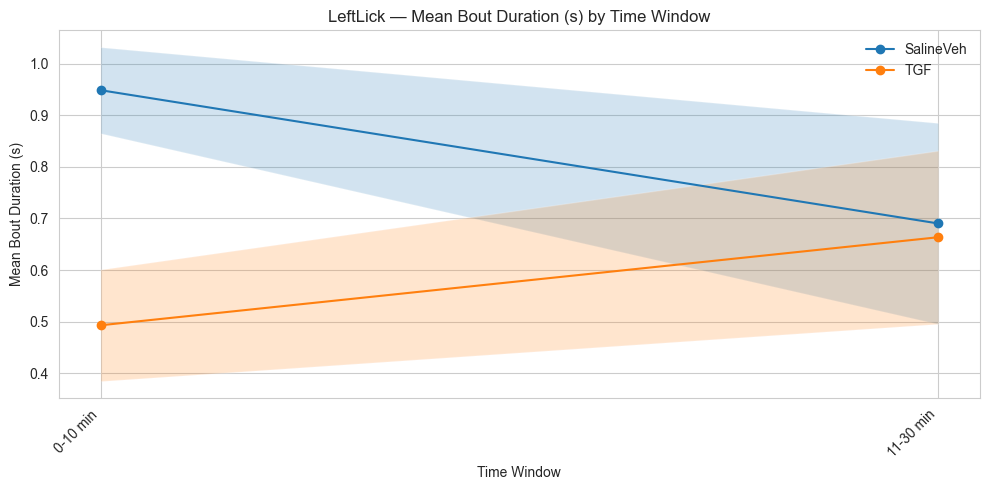

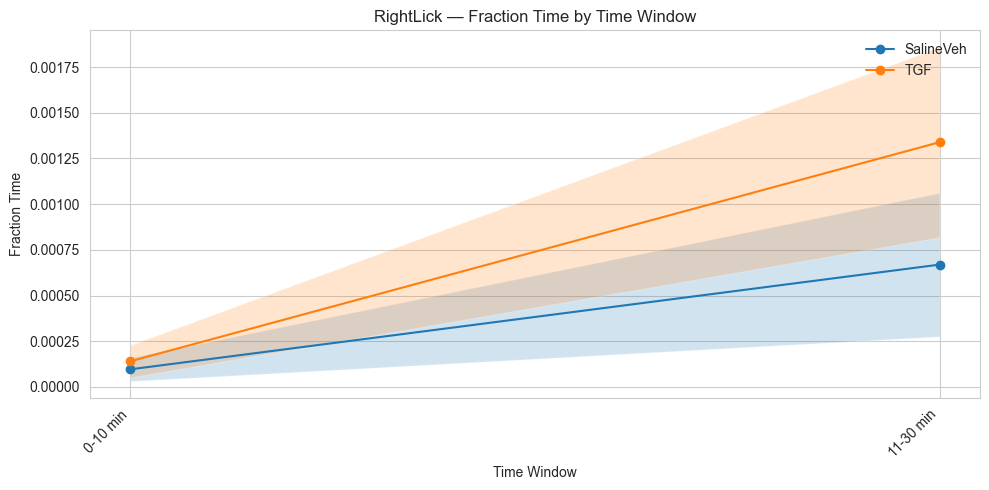

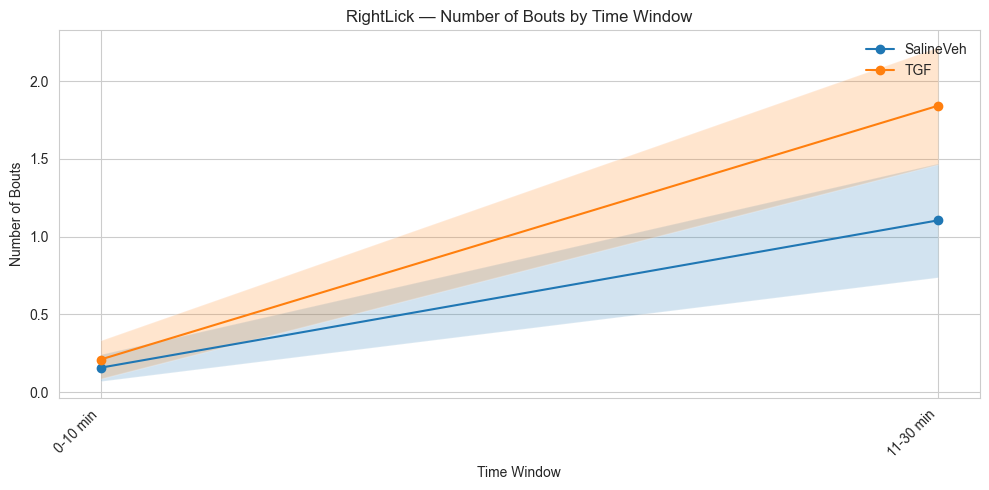

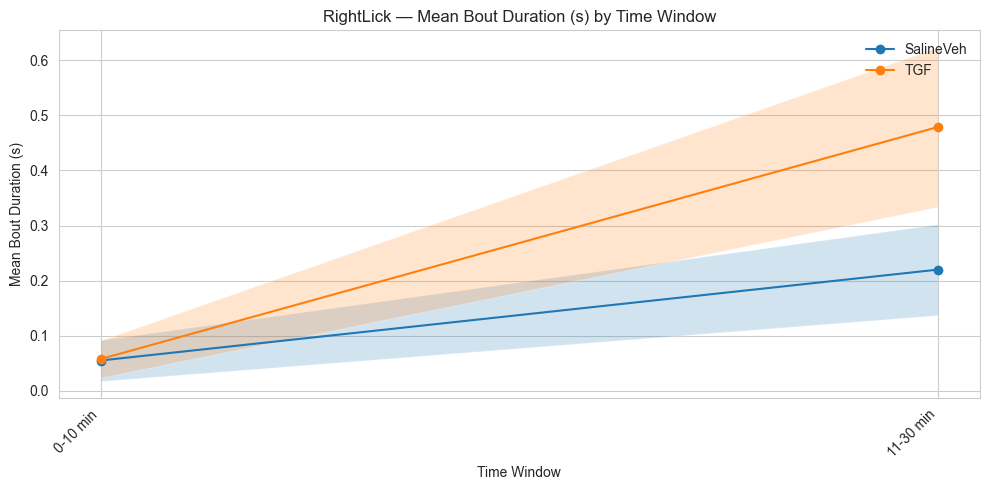

Timepoint behavior visualizations saved to: ../processed_dataset/project_Wisc_OpioidTGFSaline/figures/behaviors_LUPE-AMPS/Timepoint_Comparison/Behavior_Viz


In [12]:
### Section 2: DATA LOADING AND BEHAVIOR STATISTICS (+ Timepoint Comparison 2b/2c)

def load_lupe_data(base_dir, groups, conditions):
    """
    Load LUPE behavior CSVs organized as:
      base_dir/<group>/<condition>/*.csv

    Streamlit-consistent behavior:
      - expected_length = MAX length across all loaded files
      - pad shorter files with zeros
      - truncate longer files to expected_length

    Returns:
      behavior_matrix: (expected_length, n_animals) int
      animal_names: list[str]
      group_labels: list[str]
      condition_labels: list[str]
    """
    behavior_data = []
    animal_names = []
    group_labels = []
    condition_labels = []

    for group in groups:
        group_dir = os.path.join(base_dir, group)
        if not os.path.exists(group_dir):
            print(f"[LUPE-AMPS] Warning: Group directory not found: {group_dir}")
            continue

        for condition in conditions:
            condition_dir = os.path.join(group_dir, condition)
            if not os.path.exists(condition_dir):
                print(f"[LUPE-AMPS] Warning: Condition directory not found: {condition_dir}")
                continue

            csv_files = sorted(glob.glob(os.path.join(condition_dir, "*.csv")))
            print(f"[LUPE-AMPS] Found {len(csv_files)} files in {group}/{condition}")

            for file_path in csv_files:
                try:
                    data = pd.read_csv(file_path)

                    # Extract behavior column (2nd column, index 1)
                    behav_col = pd.to_numeric(data.iloc[:, 1], errors="coerce").fillna(0).to_numpy()
                    behav = behav_col.astype(int)

                    behavior_data.append(behav)
                    animal_names.append(os.path.splitext(os.path.basename(file_path))[0])
                    group_labels.append(group)
                    condition_labels.append(condition)

                except Exception as e:
                    print(f"[LUPE-AMPS] Error loading {file_path}: {e}")
                    continue

    if len(behavior_data) == 0:
        raise ValueError("No data files were successfully loaded! Check base_dir/groups/conditions paths.")

    # Streamlit behavior: expected_length = MAX, then pad/truncate
    lengths = np.array([len(b) for b in behavior_data], dtype=int)
    expected_length = int(np.max(lengths))

    if len(np.unique(lengths)) > 1:
        unique_lens, counts = np.unique(lengths, return_counts=True)
        print("[LUPE-AMPS] Detected variable recording lengths.")
        print(f"  Lengths (frames) distribution: {dict(zip(unique_lens.tolist(), counts.tolist()))}")
        print(f"  Using MAX length as expected_length: {expected_length} frames")

    fixed = []
    n_padded = 0
    n_truncated = 0

    for b in behavior_data:
        L = int(len(b))
        if L == expected_length:
            fixed.append(b)
        elif L > expected_length:
            fixed.append(b[:expected_length])
            n_truncated += 1
        else:
            padded = np.zeros(expected_length, dtype=b.dtype)
            padded[:L] = b
            fixed.append(padded)
            n_padded += 1

    if n_truncated > 0:
        print(f"  Truncated {n_truncated} file(s) down to {expected_length} frames.")
    if n_padded > 0:
        print(f"  Padded {n_padded} file(s) up to {expected_length} frames (zero-pad).")

    behavior_matrix = np.column_stack(fixed)
    print(f"\n[LUPE-AMPS] Loaded {behavior_matrix.shape[1]} animals, {behavior_matrix.shape[0]} frames each")

    return behavior_matrix, animal_names, group_labels, condition_labels


def find_bouts(binary_data, min_frames):
    """
    Identify bout starts/ends requiring min_frames consecutive 1s for validity.
    binary_data: 1D array of 0/1
    """
    bout_starts = []
    bout_ends = []

    diff = np.diff(binary_data)
    potential_starts = np.where(diff == 1)[0] + 1
    potential_ends = np.where(diff == -1)[0]

    for start in potential_starts:
        end_check = min(start + int(min_frames), len(binary_data))
        if np.all(binary_data[start:end_check] == 1):
            bout_starts.append(start)

    for end in potential_ends:
        start_check = max(end - int(min_frames) + 1, 0)
        if np.all(binary_data[start_check:end + 1] == 1):
            bout_ends.append(end)

    return np.array(bout_starts), np.array(bout_ends)


def calculate_behavior_statistics(behavior_matrix, n_bins, bin_length, sampling_rate, n_behaviors, min_frames):
    """
    behavior_matrix: (n_frames, n_animals) int labels [0..n_behaviors-1]
    Returns arrays shaped:
      total_fraction: (n_animals, n_bins, n_behaviors)
      n_bouts:       (n_animals, n_bins, n_behaviors)
      bout_duration: (n_animals, n_bins, n_behaviors)
    """
    n_frames, n_animals = behavior_matrix.shape

    # Bin setup
    if bin_length <= 0:
        n_bins = 1
        bin_length_frames = n_frames
    else:
        bin_length_frames = int(round(float(bin_length) * 60.0 * float(sampling_rate)))
        bin_length_frames = max(1, bin_length_frames)
        # IMPORTANT: ceil bins so you don't drop tail frames
        n_bins = int(np.ceil(n_frames / bin_length_frames))

    total_fraction = np.zeros((n_animals, n_bins, n_behaviors), dtype=float)
    n_bouts = np.zeros((n_animals, n_bins, n_behaviors), dtype=float)
    bout_duration = np.zeros((n_animals, n_bins, n_behaviors), dtype=float)

    for k in range(n_animals):
        for b in range(n_behaviors):
            binary_data = (behavior_matrix[:, k] == b).astype(int)

            for n in range(n_bins):
                if bin_length <= 0:
                    binned = binary_data
                else:
                    start_idx = int(n * bin_length_frames)
                    end_idx = int(min((n + 1) * bin_length_frames, n_frames))  # clamp end
                    binned = binary_data[start_idx:end_idx]

                if binned.size == 0:
                    continue

                if np.sum(binned) > 0:
                    bout_starts, bout_ends = find_bouts(binned, min_frames)

                    if len(bout_starts) > 0 and len(bout_ends) > 0:
                        # Align starts/ends
                        bout_ends = bout_ends[bout_ends >= bout_starts[0]]
                        if len(bout_ends) > 0:
                            bout_starts = bout_starts[bout_starts <= bout_ends[-1]]

                        if len(bout_starts) > 0 and len(bout_ends) > 0:
                            n_valid = min(len(bout_starts), len(bout_ends))
                            durations = (bout_ends[:n_valid] - bout_starts[:n_valid]) / float(sampling_rate)

                            total_fraction[k, n, b] = float(np.mean(binned))
                            n_bouts[k, n, b] = float(len(bout_starts))
                            bout_duration[k, n, b] = float(np.mean(durations)) if len(durations) > 0 else 0.0

    return total_fraction, n_bouts, bout_duration


# -----------------------------
# RUN SECTION 2 (main stats)
# -----------------------------

behavior_matrix, animal_names, group_labels, condition_labels = load_lupe_data(
    base_data_dir, selected_groups, selected_conditions
)

# Infer recording length and related parameters after loading data
original_length = int(behavior_matrix.shape[0])
recording_length = original_length / (float(sampling_rate) * 60.0)

if bin_length > 0:
    bin_length_frames = int(round(float(bin_length) * 60.0 * float(sampling_rate)))
    bin_length_frames = max(1, bin_length_frames)
    n_bins = int(np.ceil(original_length / bin_length_frames))
else:
    n_bins = 1

print(f"[LUPE-AMPS] Recording length inferred: {recording_length:.2f} minutes")
print(f"[LUPE-AMPS] Frames: {original_length} @ {sampling_rate} fps | Bins: {n_bins} (bin_length={bin_length} min)")

print("\n[LUPE-AMPS] Calculating behavior statistics...")
total_fraction, n_bouts, bout_duration = calculate_behavior_statistics(
    behavior_matrix, n_bins, bin_length, sampling_rate, n_behaviors, min_frames_true_positive
)

# Aggregate across bins
total_frac_time = np.mean(total_fraction, axis=1)  # (n_animals, n_behaviors)
total_num_bouts = np.sum(n_bouts, axis=1)          # (n_animals, n_behaviors)

weighted_dur = bout_duration * n_bouts
total_mean_dur = np.sum(weighted_dur, axis=1) / (total_num_bouts + 1e-10)
total_mean_dur = np.nan_to_num(total_mean_dur, nan=0.0, posinf=0.0, neginf=0.0)

print(f"[LUPE-AMPS] Behavior statistics calculated for {total_frac_time.shape[0]} animals")

# Export behavior statistics
output_dir_section2 = os.path.join(output_base_dir, "Section2_BehaviorStats")
os.makedirs(output_dir_section2, exist_ok=True)

for b, beh_name in enumerate(behaviors):
    df = pd.DataFrame(
        {
            "FractionTime": total_frac_time[:, b],
            "NumBouts": total_num_bouts[:, b],
            "MeanDuration_s": total_mean_dur[:, b],
        },
        index=animal_names,
    )
    df["Group"] = group_labels
    df["Condition"] = condition_labels
    df.to_csv(os.path.join(output_dir_section2, f"{beh_name}_statistics.csv"))

print(f"[LUPE-AMPS] Behavior statistics exported to: {output_dir_section2}")


# -----------------------------
# Section 2b/2c PREP (IMPORTANT)
# -----------------------------
df_behavior_timepoints = None  # prevent NameError

output_dir_timepoints = os.path.join(output_base_dir, "Timepoint_Comparison")
os.makedirs(output_dir_timepoints, exist_ok=True)
print(f"[TIMEPOINT] Output folder: {output_dir_timepoints}")


def _min_to_slice(start_min, end_min, fps, n_frames):
    """
    Convert a [start_min, end_min) time window (minutes) to a frame slice.
    Clips indices to [0, n_frames].
    """
    if fps <= 0:
        raise ValueError(f"fps must be > 0, got {fps}")

    start_frame = int(round(start_min * 60 * fps))
    end_frame = int(round(end_min * 60 * fps))

    start_frame = max(0, min(start_frame, n_frames))
    end_frame = max(0, min(end_frame, n_frames))

    return slice(start_frame, end_frame)


# -----------------------------
# Section 2b (OPTIONAL): TIMEPOINT COMPARISON — BEHAVIOR STATS
# -----------------------------
if ("time_ranges_min" not in globals()) or ("time_labels" not in globals()) or (len(time_ranges_min) == 0):
    print("[TIMEPOINT] No time windows defined — skipping Section 2b/2c.")
else:
    behavior_timepoint_rows = []

    for label, (start_min, end_min) in zip(time_labels, time_ranges_min):
        sl = _min_to_slice(start_min, end_min, sampling_rate, behavior_matrix.shape[0])

        if sl.stop <= sl.start:
            print(f"[TIMEPOINT] Skipping empty window: {label} (slice {sl.start}:{sl.stop})")
            continue

        bm_win = behavior_matrix[sl, :]

        # One bin over the entire window
        tf_win, nb_win, bd_win = calculate_behavior_statistics(
            bm_win,
            n_bins=1,
            bin_length=0,
            sampling_rate=sampling_rate,
            n_behaviors=n_behaviors,
            min_frames=min_frames_true_positive,
        )

        # (n_animals, 1, n_behaviors) -> squeeze bin dim
        tf_win = tf_win[:, 0, :]
        nb_win = nb_win[:, 0, :]
        bd_win = bd_win[:, 0, :]

        for a_idx, animal in enumerate(animal_names):
            for b_idx, beh_name in enumerate(behaviors):
                behavior_timepoint_rows.append(
                    {
                        "Time_Group": label,
                        "Start_min": start_min,
                        "End_min": end_min,
                        "Animal": animal,
                        "Group": group_labels[a_idx],
                        "Condition": condition_labels[a_idx],
                        "Behavior": beh_name,
                        "FractionTime": float(tf_win[a_idx, b_idx]),
                        "NumBouts": float(nb_win[a_idx, b_idx]),
                        "MeanDuration_s": float(bd_win[a_idx, b_idx]),
                    }
                )

    if len(behavior_timepoint_rows) > 0:
        df_behavior_timepoints = pd.DataFrame(behavior_timepoint_rows)
        csv_path = os.path.join(output_dir_timepoints, f"{project_name}_behavior_timepoint_comparison.csv")
        df_behavior_timepoints.to_csv(csv_path, index=False)
        print(f"[TIMEPOINT] Saved: {csv_path}")
        print(f"[TIMEPOINT] Rows: {len(df_behavior_timepoints)}")
    else:
        df_behavior_timepoints = None
        print("[TIMEPOINT] No timepoint rows were generated (all windows empty or clipped). Skipping 2c.")


# -----------------------------
# Section 2c (OPTIONAL): TIMEPOINT VISUALIZATION — BEHAVIOR STATS
# -----------------------------
if df_behavior_timepoints is not None and len(df_behavior_timepoints) > 0:
    output_dir_timepoints_behviz = os.path.join(output_dir_timepoints, "Behavior_Viz")
    os.makedirs(output_dir_timepoints_behviz, exist_ok=True)

    metric_dirs = {
        "FractionTime": os.path.join(output_dir_timepoints_behviz, "FractionTime"),
        "NumBouts": os.path.join(output_dir_timepoints_behviz, "NumBouts"),
        "MeanDuration_s": os.path.join(output_dir_timepoints_behviz, "MeanDuration"),
    }
    for d in metric_dirs.values():
        os.makedirs(d, exist_ok=True)

    # enforce categorical ordering for x-axis
    df_behavior_timepoints["Time_Group"] = pd.Categorical(
        df_behavior_timepoints["Time_Group"], categories=time_labels, ordered=True
    )

    metrics_to_plot = [
        ("FractionTime", "Fraction Time"),
        ("NumBouts", "Number of Bouts"),
        ("MeanDuration_s", "Mean Bout Duration (s)"),
    ]

    def _sem(x):
        return x.std(ddof=1) / np.sqrt(len(x)) if len(x) > 1 else 0.0

    # IMPORTANT: preserve user-specified ordering
    unique_groups = list(selected_groups)
    unique_conditions = list(selected_conditions)

    for beh in behaviors:
        df_b = df_behavior_timepoints[df_behavior_timepoints["Behavior"] == beh].copy()
        if df_b.empty:
            continue

        summary = (
            df_b.groupby(["Group", "Condition", "Time_Group"], observed=True)
            .agg(
                mean_FractionTime=("FractionTime", "mean"),
                sem_FractionTime=("FractionTime", _sem),
                mean_NumBouts=("NumBouts", "mean"),
                sem_NumBouts=("NumBouts", _sem),
                mean_MeanDuration_s=("MeanDuration_s", "mean"),
                sem_MeanDuration_s=("MeanDuration_s", _sem),
                n=("FractionTime", "size"),
            )
            .reset_index()
        )

        for group in unique_groups:
            summary_g = summary[summary["Group"] == group].copy()
            if summary_g.empty:
                continue

            for metric_key, metric_label in metrics_to_plot:
                mean_col = f"mean_{metric_key}"
                sem_col = f"sem_{metric_key}"

                plt.figure(figsize=(10, 5))

                for cond in unique_conditions:
                    sdf = summary_g[summary_g["Condition"] == cond].sort_values("Time_Group")
                    if sdf.empty:
                        continue

                    sdf = sdf.set_index("Time_Group").reindex(time_labels).reset_index()

                    x = np.arange(len(time_labels))
                    y = sdf[mean_col].to_numpy(dtype=float)
                    e = sdf[sem_col].to_numpy(dtype=float)

                    n_line = int(np.nanmax(sdf["n"].to_numpy(dtype=float))) if np.any(~np.isnan(sdf["n"])) else 0
                    line_label = f"{cond} (n={n_line})"

                    plt.plot(x, y, marker="o", label=line_label)
                    plt.fill_between(x, y - e, y + e, alpha=0.2)

                plt.xticks(np.arange(len(time_labels)), time_labels, rotation=45, ha="right")
                plt.xlabel("Time Window")
                plt.ylabel(metric_label)
                plt.title(f"{beh} — {metric_label} by Time Window\nGroup: {group}")
                plt.legend(frameon=False)
                plt.tight_layout()

                fname = f"{project_name}_timepoint_{group}_{beh}_{metric_key}".replace("/", "_").replace(" ", "_")
                plt.savefig(os.path.join(metric_dirs[metric_key], f"{fname}.png"), dpi=300)
                plt.savefig(os.path.join(metric_dirs[metric_key], f"{fname}.svg"))
                plt.show()

    print(f"[TIMEPOINT] Timepoint behavior visualizations saved to: {output_dir_timepoints_behviz}")
else:
    print("[TIMEPOINT] Skipping Section 2c: df_behavior_timepoints not available or empty.")

### Section 3: BEHAVIOR VISUALIZATION

Conditions (sorted): ['SalineVeh', 'TGF']


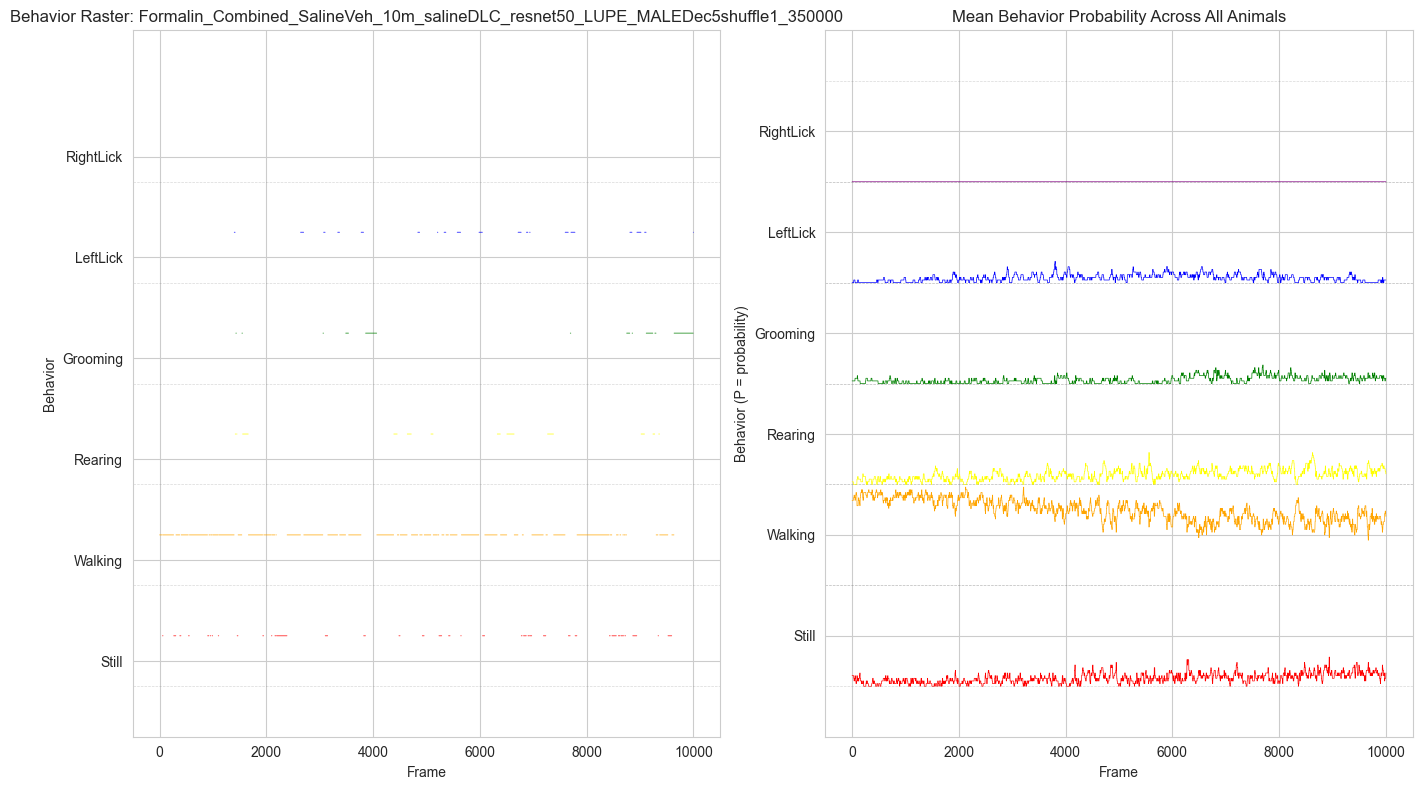

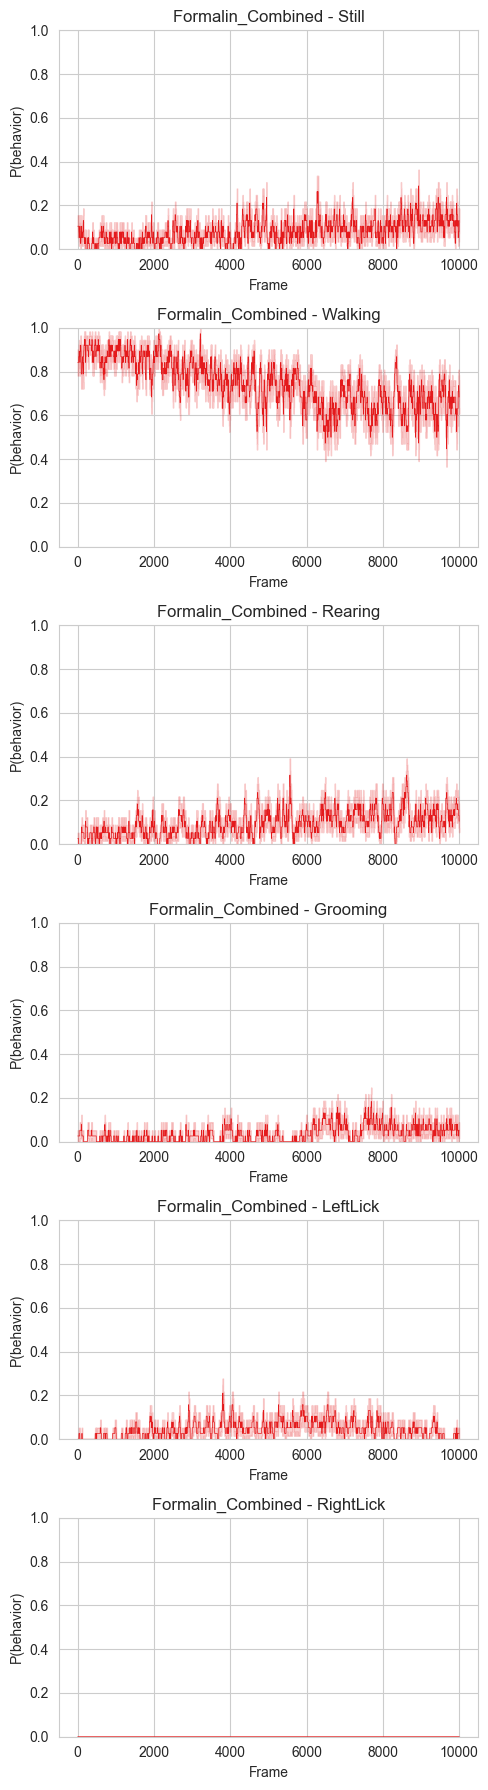

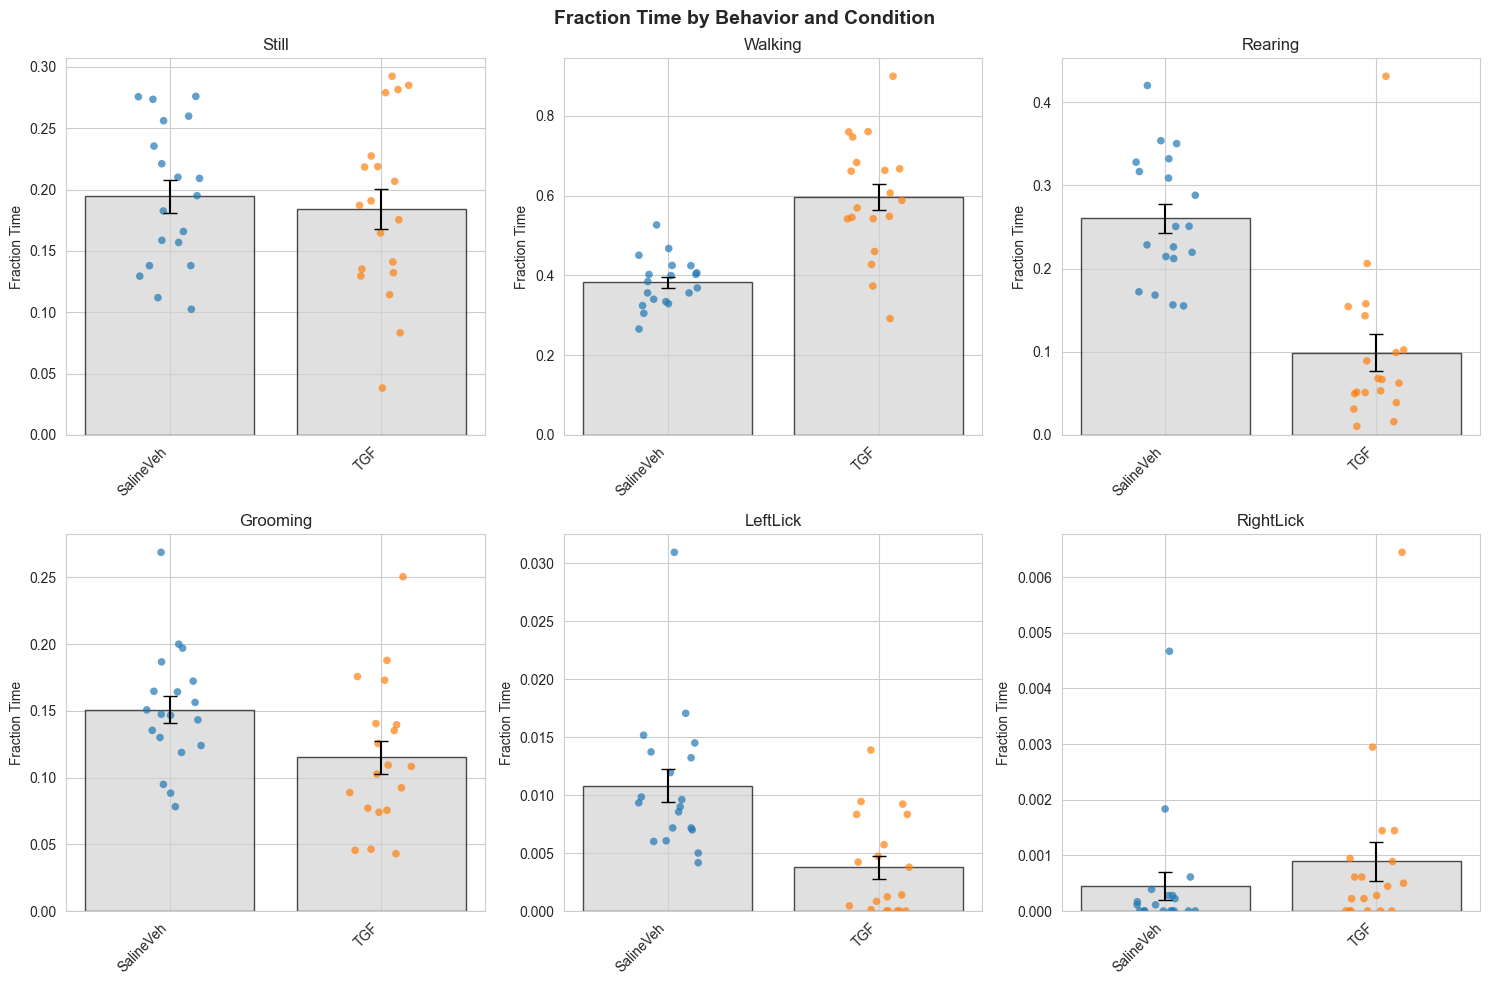

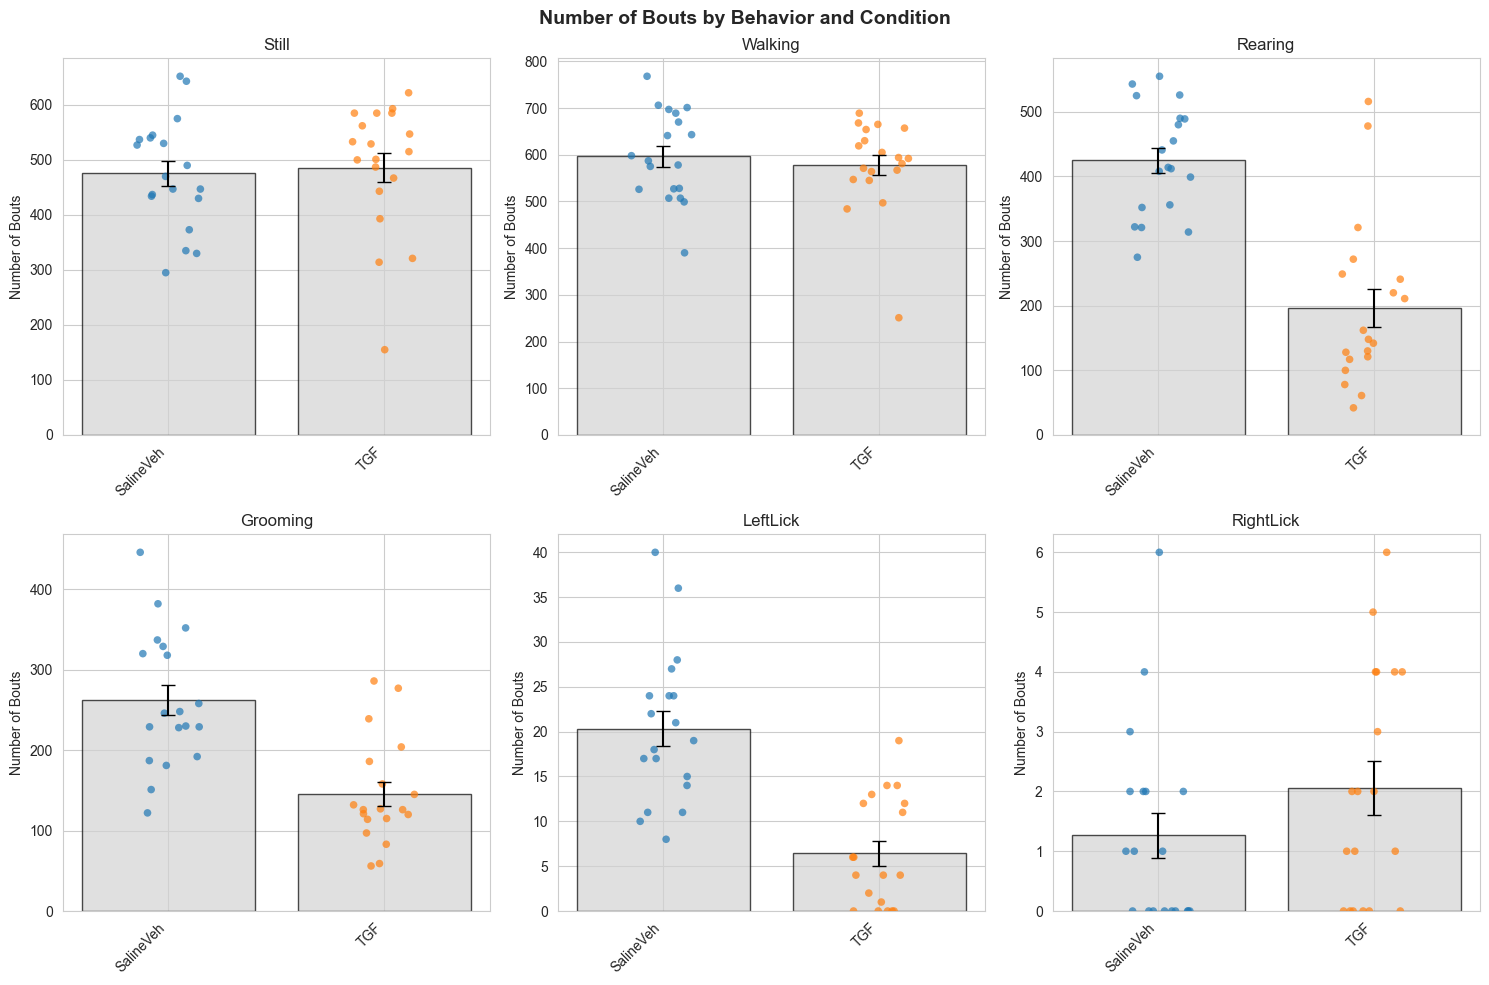

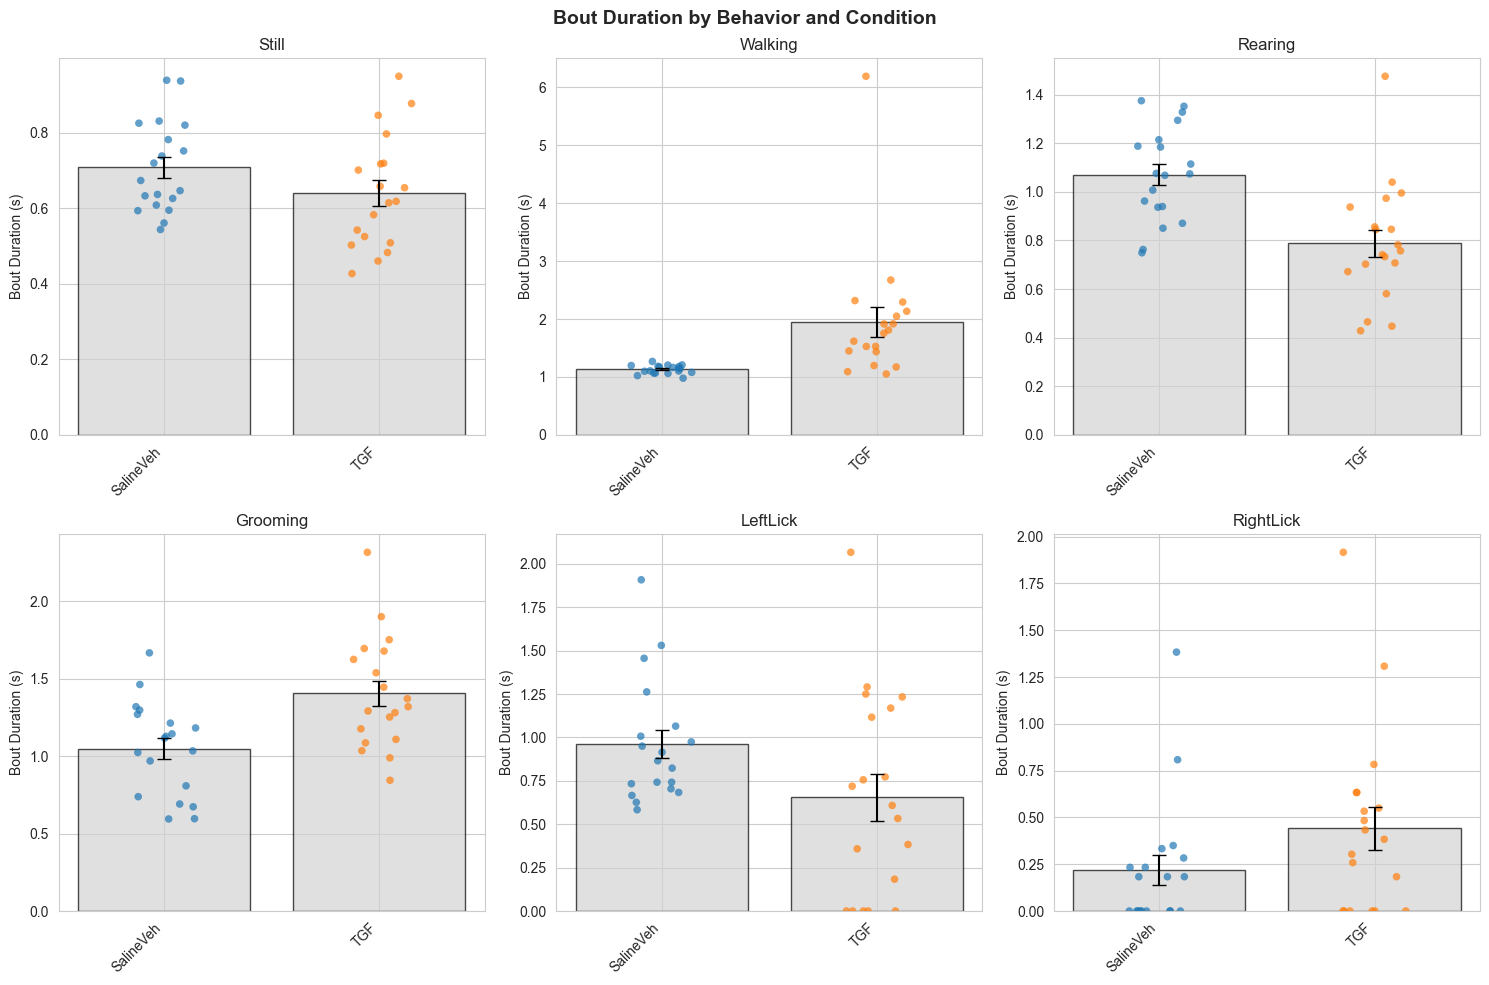

Behavior visualizations saved to: ../processed_dataset/project_Wisc_OpioidTGFSaline/figures/behaviors_LUPE-AMPS/Section3_BehaviorViz


In [13]:
output_dir_section3 = os.path.join(output_base_dir, 'Section3_BehaviorViz')
os.makedirs(output_dir_section3, exist_ok=True)

behavior_colors = ['red', 'orange', 'yellow', 'green', 'blue', 'purple']

unique_conditions = sorted(list(set(condition_labels)))
palette = sns.color_palette('tab10', len(unique_conditions))
condition_colors = dict(zip(unique_conditions, palette))

print(f"Conditions (sorted): {unique_conditions}")

# 3a. Plot behavior raster for single animal and average across all animals
# Binary occurrence of each behavior over time, stacked vertically
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

animal_of_interest = 0
time_window = slice(0, min(10000, behavior_matrix.shape[0]))
frames = np.arange(time_window.start, time_window.stop)

ax = axes[0]
for b in range(n_behaviors):
    beh_trace = (behavior_matrix[time_window, animal_of_interest] == b).astype(float)
    beh_trace_plot = beh_trace * 0.5 + b
    beh_trace_plot[beh_trace == 0] = np.nan
    ax.plot(frames, beh_trace_plot, color=behavior_colors[b], linewidth=0.5, label=behaviors[b])
    ax.axhline(y=b, color='gray', linestyle='--', alpha=0.3, linewidth=0.5)

ax.set_ylim(-0.5, n_behaviors + 0.5)
ax.set_yticks(np.arange(n_behaviors) + 0.25)
ax.set_yticklabels(behaviors)
ax.set_xlabel('Frame')
ax.set_ylabel('Behavior')
ax.set_title(f'Behavior Raster: {animal_names[animal_of_interest]}')

ax = axes[1]
for b in range(n_behaviors):
    beh_prob = (behavior_matrix[time_window, :] == b).astype(float).mean(axis=1)
    ax.plot(frames, beh_prob + b, color=behavior_colors[b], linewidth=0.5, label=behaviors[b])
    ax.axhline(y=b, color='gray', linestyle='--', alpha=0.3, linewidth=0.5)
    ax.axhline(y=b + 1, color='gray', linestyle='--', alpha=0.3, linewidth=0.5)

ax.set_ylim(-0.5, n_behaviors + 0.5)
ax.set_yticks(np.arange(n_behaviors) + 0.5)
ax.set_yticklabels(behaviors)
ax.set_xlabel('Frame')
ax.set_ylabel('Behavior (P = probability)')
ax.set_title('Mean Behavior Probability Across All Animals')

plt.tight_layout()
plt.savefig(os.path.join(output_dir_section3, f'{project_name}_behavior_raster.png'), dpi=300)
plt.savefig(os.path.join(output_dir_section3, f'{project_name}_behavior_raster.svg'))
plt.show()

# 3b. Plot behavior probability over time by GROUP (like MATLAB Section 3b)
unique_groups = sorted(list(set(group_labels)))
time_window_prob = slice(0, min(10000, behavior_matrix.shape[0]))

fig, axes = plt.subplots(n_behaviors, len(unique_groups), figsize=(5 * len(unique_groups), 3 * n_behaviors))
if len(unique_groups) == 1:
    axes = axes.reshape(-1, 1)

group_colors = dict(zip(unique_groups, sns.color_palette('Set1', len(unique_groups))))

for b in range(n_behaviors):
    for g_idx, group in enumerate(unique_groups):
        ax = axes[b, g_idx]
        
        group_mask = np.array([gl == group for gl in group_labels])
        group_data = behavior_matrix[time_window_prob, :][:, group_mask]
        
        beh_binary = (group_data == b).astype(float)
        
        mean_beh = np.mean(beh_binary, axis=1)
        sem_beh = np.std(beh_binary, axis=1, ddof=1) / np.sqrt(beh_binary.shape[1])
        
        frames = np.arange(len(mean_beh))
        ax.plot(frames, mean_beh, color=group_colors[group], linewidth=0.5)
        ax.fill_between(frames, mean_beh - sem_beh, mean_beh + sem_beh, 
                        color=group_colors[group], alpha=0.2)
        
        ax.set_ylim(0, 1)
        ax.set_xlabel('Frame')
        ax.set_ylabel('P(behavior)')
        ax.set_title(f'{group} - {behaviors[b]}')

plt.tight_layout()
plt.savefig(os.path.join(output_dir_section3, f'{project_name}_behavior_probability_by_group.png'), dpi=300)
plt.savefig(os.path.join(output_dir_section3, f'{project_name}_behavior_probability_by_group.svg'))
plt.show()

# 3c. Plot behavior statistics by condition (bar plots with individual points)
# Fraction Time, Number of Bouts, Bout Duration - with SORTED x-axis
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for b, beh_name in enumerate(behaviors):
    ax = axes[b]
    
    means = []
    sems = []
    
    for cond in unique_conditions:  
        mask = np.array([c == cond for c in condition_labels])
        data = total_frac_time[mask, b]
        means.append(np.mean(data))
        sems.append(np.std(data, ddof=1) / np.sqrt(len(data)) if len(data) > 1 else 0)
    
    x = np.arange(len(unique_conditions))
    ax.bar(x, means, yerr=sems, capsize=5, color='lightgray', edgecolor='black', alpha=0.7)
    
    for i, cond in enumerate(unique_conditions):
        mask = np.array([c == cond for c in condition_labels])
        data = total_frac_time[mask, b]
        jitter = np.random.uniform(-0.15, 0.15, size=len(data))
        ax.scatter(np.ones(len(data)) * i + jitter, data, 
                   c=[condition_colors[cond]], s=30, alpha=0.7, edgecolors='none')
    
    ax.set_xticks(x)
    ax.set_xticklabels(unique_conditions, rotation=45, ha='right')
    ax.set_ylabel('Fraction Time')
    ax.set_title(beh_name)

plt.suptitle('Fraction Time by Behavior and Condition', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(output_dir_section3, f'{project_name}_behavior_fraction_by_condition.png'), dpi=300)
plt.savefig(os.path.join(output_dir_section3, f'{project_name}_behavior_fraction_by_condition.svg'))
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for b, beh_name in enumerate(behaviors):
    ax = axes[b]
    
    means = []
    sems = []
    
    for cond in unique_conditions:
        mask = np.array([c == cond for c in condition_labels])
        data = total_num_bouts[mask, b]
        means.append(np.mean(data))
        sems.append(np.std(data, ddof=1) / np.sqrt(len(data)) if len(data) > 1 else 0)
    
    x = np.arange(len(unique_conditions))
    ax.bar(x, means, yerr=sems, capsize=5, color='lightgray', edgecolor='black', alpha=0.7)
    
    for i, cond in enumerate(unique_conditions):
        mask = np.array([c == cond for c in condition_labels])
        data = total_num_bouts[mask, b]
        jitter = np.random.uniform(-0.15, 0.15, size=len(data))
        ax.scatter(np.ones(len(data)) * i + jitter, data,
                   c=[condition_colors[cond]], s=30, alpha=0.7, edgecolors='none')
    
    ax.set_xticks(x)
    ax.set_xticklabels(unique_conditions, rotation=45, ha='right')
    ax.set_ylabel('Number of Bouts')
    ax.set_title(beh_name)

plt.suptitle('Number of Bouts by Behavior and Condition', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(output_dir_section3, f'{project_name}_behavior_bouts_by_condition.png'), dpi=300)
plt.savefig(os.path.join(output_dir_section3, f'{project_name}_behavior_bouts_by_condition.svg'))
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for b, beh_name in enumerate(behaviors):
    ax = axes[b]
    
    means = []
    sems = []
    
    for cond in unique_conditions:
        mask = np.array([c == cond for c in condition_labels])
        data = total_mean_dur[mask, b]
        means.append(np.mean(data))
        sems.append(np.std(data, ddof=1) / np.sqrt(len(data)) if len(data) > 1 else 0)
    
    x = np.arange(len(unique_conditions))
    ax.bar(x, means, yerr=sems, capsize=5, color='lightgray', edgecolor='black', alpha=0.7)
    
    for i, cond in enumerate(unique_conditions):
        mask = np.array([c == cond for c in condition_labels])
        data = total_mean_dur[mask, b]
        jitter = np.random.uniform(-0.15, 0.15, size=len(data))
        ax.scatter(np.ones(len(data)) * i + jitter, data,
                   c=[condition_colors[cond]], s=30, alpha=0.7, edgecolors='none')
    
    ax.set_xticks(x)
    ax.set_xticklabels(unique_conditions, rotation=45, ha='right')
    ax.set_ylabel('Bout Duration (s)')
    ax.set_title(beh_name)

plt.suptitle('Bout Duration by Behavior and Condition', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(output_dir_section3, f'{project_name}_behavior_duration_by_condition.png'), dpi=300)
plt.savefig(os.path.join(output_dir_section3, f'{project_name}_behavior_duration_by_condition.svg'))
plt.show()

print(f"Behavior visualizations saved to: {output_dir_section3}")

### Section 4: PREPROCESSING - DOWNSAMPLING

In [14]:
def flip_injury_site(behavior_matrix, injury_site):
    """Flip left/right lick labels if injury was on right paw."""
    if injury_site == 0:
        return behavior_matrix  # No change needed - left paw is default
    
    # Right paw injury - swap labels 4 and 5
    flipped = behavior_matrix.copy()
    mask_4 = flipped == 4
    mask_5 = flipped == 5
    flipped[mask_4] = 5
    flipped[mask_5] = 4
    
    return flipped


def downsample_behavior(behavior_matrix, sampling_rate, target_fps):
    """Downsample behavior from original fps to target fps using mode."""
    rate_ratio = target_fps / sampling_rate
    n_downsampled = int(behavior_matrix.shape[0] * rate_ratio)
    n_animals = behavior_matrix.shape[1]
    
    downsampled = np.zeros((n_downsampled, n_animals), dtype=int)
    
    for n in range(n_downsampled - 1):
        start_idx = int(n / rate_ratio)
        end_idx = int((n + 1) / rate_ratio)
        
        for a in range(n_animals):
            window = behavior_matrix[start_idx:end_idx, a]
            if len(window) > 0:
                mode_result = mode(window, keepdims=False)
                downsampled[n, a] = int(np.floor(mode_result.mode))
    
    return downsampled


# Flip injury sites if needed (right paw injury -> swap labels 4 and 5)
# Downsample from original fps to target fps
try:
    behavior_matrix_flipped = flip_injury_site(behavior_matrix, injury_site)
    behavior_ds = downsample_behavior(behavior_matrix_flipped, sampling_rate, target_fps)
    
    print("=" * 60)
    print("SECTION 4: PREPROCESSING COMPLETE ✅")
    print("=" * 60)
    print(f"  Injury site: {'LEFT' if injury_site == 0 else 'RIGHT'} hindpaw")
    print(f"  Downsampled: {sampling_rate} fps → {target_fps} fps")
    print(f"  Original shape: {behavior_matrix.shape}")
    print(f"  Downsampled shape: {behavior_ds.shape}")
    print("=" * 60)

except Exception as e:
    print("=" * 60)
    print("SECTION 4: PREPROCESSING FAILED ❌")
    print("=" * 60)
    print(f"  Error: {e}")
    print("=" * 60)
    raise

SECTION 4: PREPROCESSING COMPLETE ✅
  Injury site: LEFT hindpaw
  Downsampled: 60 fps → 20 fps
  Original shape: (108000, 38)
  Downsampled shape: (36000, 38)


### Section 5: GENERATE TRANSITION MATRICES

In [15]:
def generate_transition_matrices(behavior_ds, n_behaviors, window_size, window_slide):
    """Generate unfolded transition matrices for each animal."""
    n_animals = behavior_ds.shape[1]
    total_frames = behavior_ds.shape[0]
    
    # Calculate window boundaries
    wins = np.arange(0, total_frames, window_slide)
    wins = wins[wins + window_size < total_frames]
    n_wins = len(wins)
    
    print(f"Generating {n_wins} transition matrices per animal...")
    
    trans_unfolded = np.zeros((n_wins, n_behaviors**2, n_animals))
    
    for a in range(n_animals):
        # Add 1 to convert from 0-indexed to 1-indexed (MATLAB convention)
        data = behavior_ds[:, a] + 1
        
        for t in range(n_wins):
            start_idx = wins[t]
            end_idx = start_idx + window_size
            window = data[start_idx:end_idx]
            
            # Calculate transition matrix
            T = np.zeros((n_behaviors, n_behaviors))
            
            for n in range(1, n_behaviors + 1):
                for l in range(1, n_behaviors + 1):
                    idx = np.where(window == n)[0]
                    idx = idx[idx < len(window) - 1]
                    
                    if len(idx) > 0:
                        T[n-1, l-1] = np.mean(window[idx + 1] == l)
            
            trans_unfolded[t, :, a] = T.flatten()
    
    # Replace NaNs with zeros
    trans_unfolded = np.nan_to_num(trans_unfolded, nan=0.0)
    
    return trans_unfolded, wins, n_wins

# Generate transition matrices
trans_unfolded, wins, n_wins = generate_transition_matrices(
    behavior_ds, n_behaviors, window_size, window_slide
)
print(f"Transition matrices shape: {trans_unfolded.shape}")
print(f"  - {n_wins} time windows")
print(f"  - {n_behaviors**2} features (unfolded {n_behaviors}x{n_behaviors} matrix)")
print(f"  - {trans_unfolded.shape[2]} animals")

Generating 177 transition matrices per animal...
Transition matrices shape: (177, 36, 38)
  - 177 time windows
  - 36 features (unfolded 6x6 matrix)
  - 38 animals


### Section 6: APPLY STATE MODEL

Loading state centroids from: ../model/panpainmodel30.mat
Centroids shape: (6, 36)
State assignments shape: (177, 38)
Frame-level states shape: (36000, 38)
Calculating shuffled model fits (100 iterations)...

Calculating behavior transitions per state...
Calculating state-to-state transitions...

Generating behavior transition matrices per state...


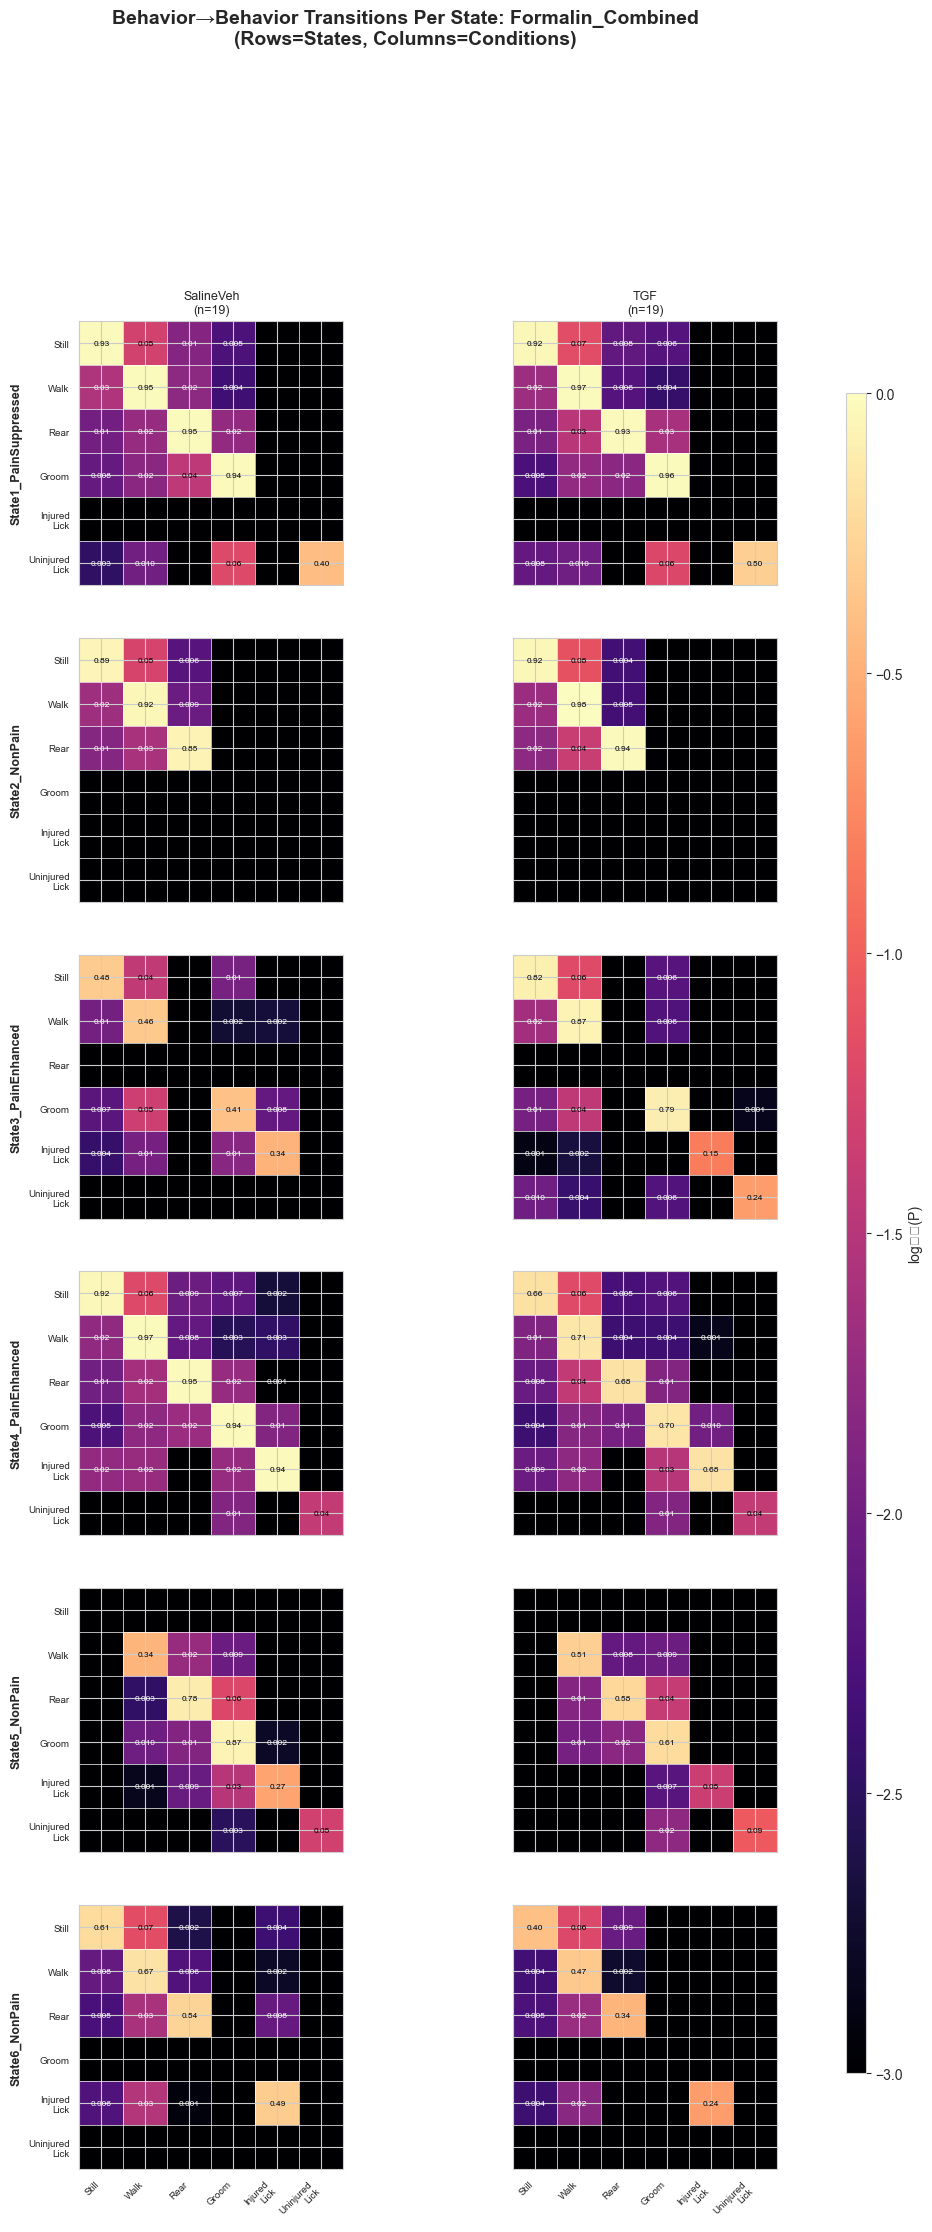

  - Saved behavior transitions for Formalin_Combined

Behavior transitions per state saved to: ../processed_dataset/project_Wisc_OpioidTGFSaline/figures/behaviors_LUPE-AMPS/Section6_StateModel/behavior_transitions_per_state/

Generating state-to-state transition matrices...


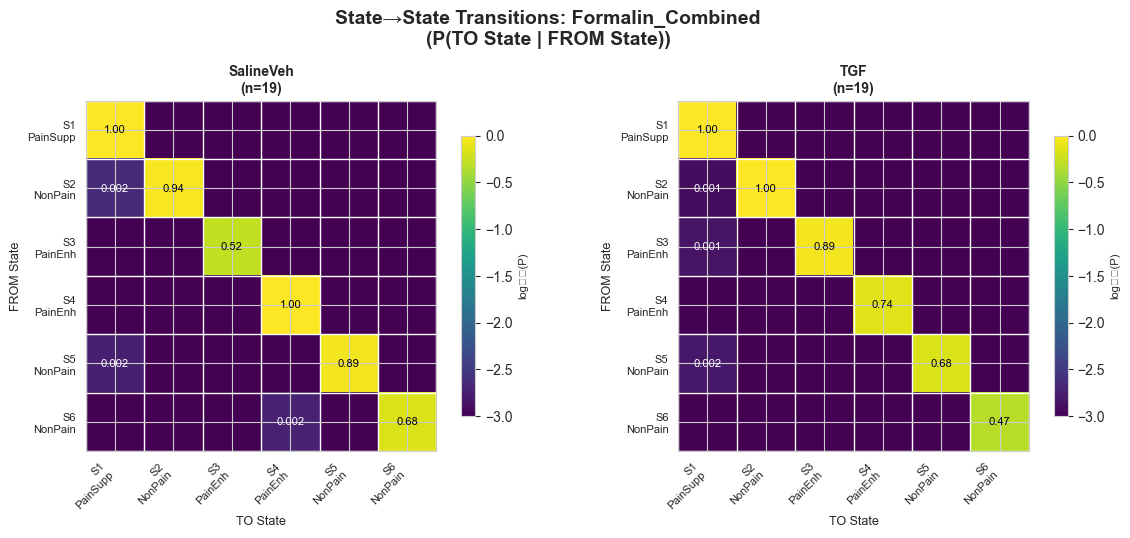

  - Saved state transitions for Formalin_Combined

State-to-state transitions saved to: ../processed_dataset/project_Wisc_OpioidTGFSaline/figures/behaviors_LUPE-AMPS/Section6_StateModel/state_to_state_transitions/

Generating model fit validation...


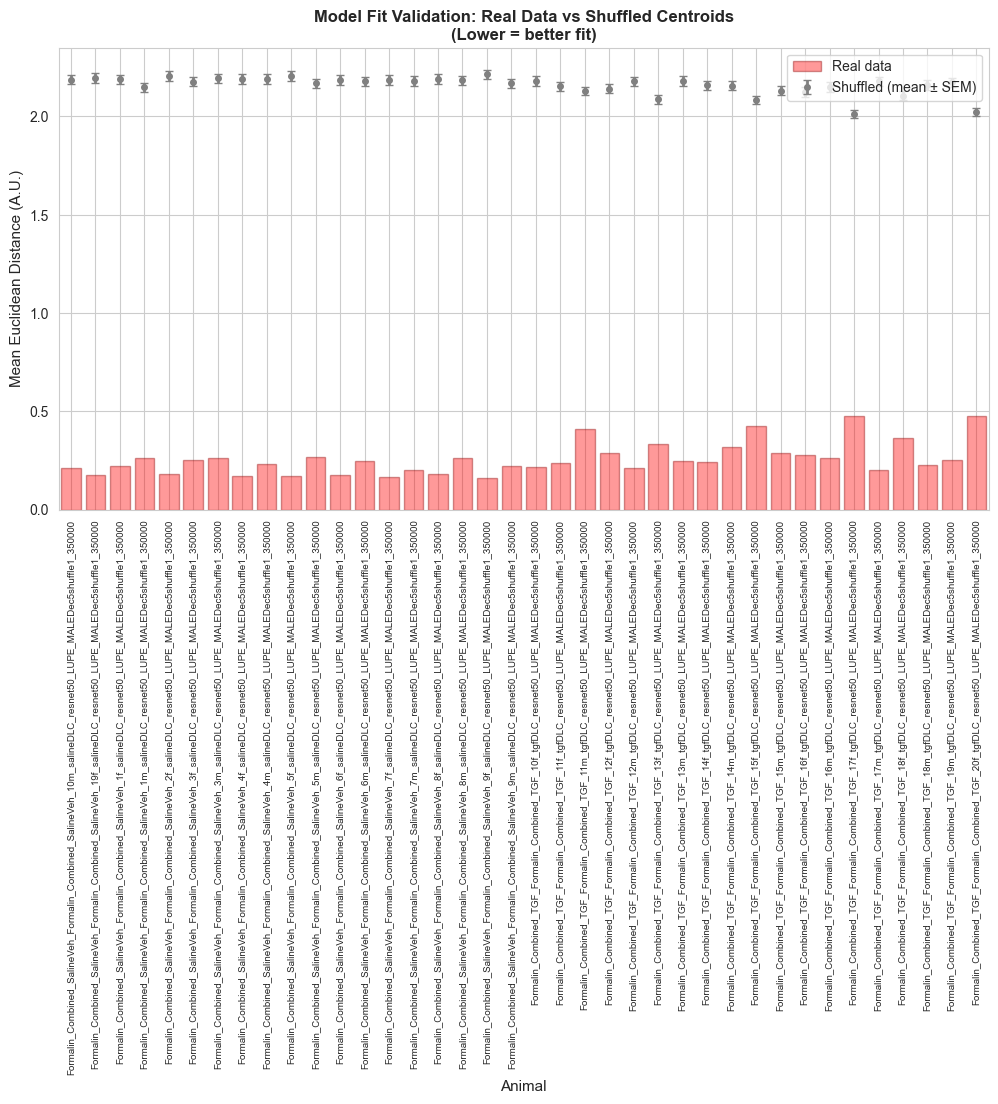

Model fit validation saved to: ../processed_dataset/project_Wisc_OpioidTGFSaline/figures/behaviors_LUPE-AMPS/Section6_StateModel/model_fit_validation/

Exporting individual state fractions...
Individual state fractions saved to: ../processed_dataset/project_Wisc_OpioidTGFSaline/figures/behaviors_LUPE-AMPS/Section6_StateModel/individual_state_fractions/

SECTION 6: STATE MODEL COMPLETE ✅
  States assigned for 38 animals
  Groups: ['Formalin_Combined']
  Conditions: ['SalineVeh', 'TGF']
  Real model fit (mean ± SEM): 0.2577 ± 0.0132
  Shuffled model fit (mean): 2.1593

Output directory: ../processed_dataset/project_Wisc_OpioidTGFSaline/figures/behaviors_LUPE-AMPS/Section6_StateModel/

  behavior_transitions_per_state/
    - project_Wisc_OpioidTGFSaline_behavior_transitions_per_state_{group}.png/svg
    - project_Wisc_OpioidTGFSaline_behavior_trans_{group}_{condition}_State{1-6}.csv
    - project_Wisc_OpioidTGFSaline_behavior_transitions_per_state_all.csv

  state_to_state_transitions/
  

In [16]:
def load_state_centroids(model_path):
    """Load pre-trained state centroids from file."""
    if model_path.endswith('.pkl'):
        with open(model_path, 'rb') as f:
            data = pickle.load(f)
            if isinstance(data, dict):
                for key in ['centroids', 'c', 'centers']:
                    if key in data:
                        return np.array(data[key])
            return np.array(data)
    elif model_path.endswith('.npy'):
        return np.load(model_path)
    elif model_path.endswith('.mat'):
        from scipy.io import loadmat
        data = loadmat(model_path)
        for key in ['c', 'centroids', 'centers']:
            if key in data:
                return np.array(data[key]).squeeze()
        raise KeyError(f"Could not find centroids in .mat file. Keys: {list(data.keys())}")
    else:
        raise ValueError(f"Unsupported file format: {model_path}")


def assign_states(trans_unfolded, centroids):
    """Assign states based on minimum distance to centroids."""
    n_wins, n_features, n_animals = trans_unfolded.shape

    state_assignments = np.zeros((n_wins, n_animals), dtype=int)
    min_distances = np.zeros((n_wins, n_animals))

    for a in range(n_animals):
        data = trans_unfolded[:, :, a]
        distances = cdist(data, centroids, metric='euclidean')
        state_assignments[:, a] = np.argmin(distances, axis=1) + 1  # 1-indexed
        min_distances[:, a] = np.min(distances, axis=1)

    return state_assignments, min_distances


def resample_states(state_assignments, window_slide, window_size, target_length):
    """Resample state assignments from window-level to frame-level."""
    n_wins, n_animals = state_assignments.shape
    behav_state = np.zeros((target_length, n_animals), dtype=int)

    for a in range(n_animals):
        for t in range(n_wins):
            start_idx = window_slide * t
            end_idx = min(start_idx + window_size, target_length)
            behav_state[start_idx:end_idx, a] = state_assignments[t, a]

    return behav_state


def calculate_model_fit(trans_unfolded, centroids, n_shuffles=100):
    """Calculate model fit compared to shuffled centroids."""
    n_wins, n_features, n_animals = trans_unfolded.shape

    # Real model fit
    _, real_distances = assign_states(trans_unfolded, centroids)
    real_fit = np.mean(real_distances, axis=0)

    # Shuffled fits
    print(f"Calculating shuffled model fits ({n_shuffles} iterations)...")
    shuffled_fit = np.zeros((n_animals, n_shuffles))

    for v in range(n_shuffles):
        perm = np.random.permutation(n_features)
        shuffled_centroids = centroids[:, perm]

        for a in range(n_animals):
            data = trans_unfolded[:, :, a]
            distances = cdist(data, shuffled_centroids, metric='euclidean')
            shuffled_fit[a, v] = np.mean(np.min(distances, axis=1))

    return real_fit, shuffled_fit

def calculate_behavior_transitions_per_state(behavior_ds, behav_state, n_behaviors, n_states):
    """
    Calculate behavior→behavior transition matrices WITHIN each state.
    Returns: dict[state] = (n_animals, n_behaviors, n_behaviors) array of transition probabilities
    """
    n_frames, n_animals = behavior_ds.shape

    # Initialize: for each state, store transition counts per animal
    state_transitions = {}
    for s in range(1, n_states + 1):
        state_transitions[s] = np.zeros((n_animals, n_behaviors, n_behaviors))

    for a in range(n_animals):
        for t in range(n_frames - 1):
            current_state = behav_state[t, a]
            current_behavior = behavior_ds[t, a]
            next_behavior = behavior_ds[t + 1, a]

            if current_state >= 1 and current_state <= n_states:
                if current_behavior < n_behaviors and next_behavior < n_behaviors:
                    state_transitions[current_state][a, current_behavior, next_behavior] += 1

    # Convert counts to probabilities
    for s in range(1, n_states + 1):
        for a in range(n_animals):
            for b in range(n_behaviors):
                row_sum = np.sum(state_transitions[s][a, b, :])
                if row_sum > 0:
                    state_transitions[s][a, b, :] /= row_sum

    return state_transitions


def calculate_state_transitions(behav_state, n_states):
    """
    Calculate state→state transition matrices.
    Returns: (n_animals, n_states, n_states) array of transition probabilities
    """
    n_frames, n_animals = behav_state.shape

    state_trans = np.zeros((n_animals, n_states, n_states))

    for a in range(n_animals):
        for t in range(n_frames - 1):
            current_state = behav_state[t, a]
            next_state = behav_state[t + 1, a]

            if current_state >= 1 and current_state <= n_states and next_state >= 1 and next_state <= n_states:
                state_trans[a, current_state - 1, next_state - 1] += 1

    for a in range(n_animals):
        for s in range(n_states):
            row_sum = np.sum(state_trans[a, s, :])
            if row_sum > 0:
                state_trans[a, s, :] /= row_sum

    return state_trans


# LOAD MODEL AND ASSIGN STATES
print(f"Loading state centroids from: {model_path}")
try:
    centroids = load_state_centroids(model_path)
    print(f"Centroids shape: {centroids.shape}")
except Exception as e:
    print(f"Error loading centroids: {e}")
    raise ValueError("Cannot proceed without valid state centroids. Please check model_path.")

# Assign states to each animal
state_assignments, min_distances = assign_states(trans_unfolded, centroids)
print(f"State assignments shape: {state_assignments.shape}")

# Resample to frame-level
behav_state = resample_states(state_assignments, window_slide, window_size, behavior_ds.shape[0])
print(f"Frame-level states shape: {behav_state.shape}")

# Calculate model fit
real_fit, shuffled_fit = calculate_model_fit(trans_unfolded, centroids, n_shuffles=100)
shuffled_mean = np.mean(shuffled_fit, axis=1)
shuffled_sem = np.std(shuffled_fit, axis=1, ddof=1) / np.sqrt(shuffled_fit.shape[1])

# CREATE OUTPUT DIRECTORY STRUCTURE
output_dir_section6 = os.path.join(output_base_dir, 'Section6_StateModel')
output_dir_behavior_trans = os.path.join(output_dir_section6, 'behavior_transitions_per_state')
output_dir_state_trans = os.path.join(output_dir_section6, 'state_to_state_transitions')
output_dir_modelfit = os.path.join(output_dir_section6, 'model_fit_validation')
output_dir_statefractions = os.path.join(output_dir_section6, 'individual_state_fractions')

os.makedirs(output_dir_behavior_trans, exist_ok=True)
os.makedirs(output_dir_state_trans, exist_ok=True)
os.makedirs(output_dir_modelfit, exist_ok=True)
os.makedirs(output_dir_statefractions, exist_ok=True)

# State column names (descriptive)
state_column_names = {
    1: 'State1_PainSuppressed',
    2: 'State2_NonPain',
    3: 'State3_PainEnhanced',
    4: 'State4_PainEnhanced',
    5: 'State5_NonPain',
    6: 'State6_NonPain'
}

# State descriptions (short form for plot labels)
state_short_names = {
    1: 'S1\nPainSupp',
    2: 'S2\nNonPain',
    3: 'S3\nPainEnh',
    4: 'S4\nPainEnh',
    5: 'S5\nNonPain',
    6: 'S6\nNonPain'
}

# Behavior labels
behaviors_redefined = ['Still', 'Walk', 'Rear', 'Groom', 'Injured\nLick', 'Uninjured\nLick']
behaviors_csv = ['Still', 'Walk', 'Rear', 'Groom', 'Injured_Lick', 'Uninjured_Lick']

# Get unique groups and conditions (sorted)
unique_groups = sorted(list(set(group_labels)))
unique_conditions = sorted(list(set(condition_labels)))

n_states = 6

# CALCULATE TRANSITIONS
print("\nCalculating behavior transitions per state...")
behavior_trans_per_state = calculate_behavior_transitions_per_state(
    behavior_ds, behav_state, n_behaviors, n_states
)

print("Calculating state-to-state transitions...")
state_trans = calculate_state_transitions(behav_state, n_states)

# FIGURE 1: BEHAVIOR→BEHAVIOR TRANSITIONS PER STATE
# One figure per group, with states as rows and conditions as columns
print("\nGenerating behavior transition matrices per state...")

all_behavior_trans_data = []

for group in unique_groups:
    # Create figure: rows = 6 states, columns = conditions
    n_conds = len(unique_conditions)

    fig, axes = plt.subplots(n_states, n_conds, figsize=(5 * n_conds, 4 * n_states))
    if n_conds == 1:
        axes = axes.reshape(-1, 1)

    for state_idx in range(n_states):
        state = state_idx + 1

        for cond_idx, cond in enumerate(unique_conditions):
            ax = axes[state_idx, cond_idx]

            mask = np.array([(g == group and c == cond) for g, c in zip(group_labels, condition_labels)])
            n_animals_subset = np.sum(mask)

            if n_animals_subset == 0:
                ax.text(0.5, 0.5, 'No data', ha='center', va='center', fontsize=10)
                ax.set_title(f'{cond}', fontsize=9)
                ax.axis('off')
                continue

            # Get transition matrices for this state, group, condition
            animal_indices = np.where(mask)[0]
            trans_matrices = behavior_trans_per_state[state][animal_indices, :, :]

            # Mean across animals
            mean_trans = np.mean(trans_matrices, axis=0)

            # Log transform for visualization
            trans_log = np.log10(mean_trans + 1e-10)

            im = ax.imshow(trans_log, cmap='magma', aspect='equal', vmin=-3, vmax=0)

            for i in range(n_behaviors):
                for j in range(n_behaviors):
                    value = mean_trans[i, j]
                    text_color = 'white' if trans_log[i, j] < -1.5 else 'black'
                    if value >= 0.01:
                        text = f'{value:.2f}'
                    elif value >= 0.001:
                        text = f'{value:.3f}'
                    else:
                        text = ''  # Don't show very small values
                    ax.text(j, i, text, ha='center', va='center', fontsize=6, color=text_color)

            ax.set_xticks(np.arange(-0.5, n_behaviors, 1), minor=True)
            ax.set_yticks(np.arange(-0.5, n_behaviors, 1), minor=True)
            ax.grid(which='minor', color='white', linestyle='-', linewidth=0.5)

            ax.set_xticks(range(n_behaviors))
            ax.set_yticks(range(n_behaviors))

            if state_idx == n_states - 1:  # Bottom row
                ax.set_xticklabels(behaviors_redefined, rotation=45, ha='right', fontsize=7)
            else:
                ax.set_xticklabels([])

            if cond_idx == 0:  # First column
                ax.set_yticklabels(behaviors_redefined, fontsize=7)
                ax.set_ylabel(f'{state_column_names[state]}', fontsize=9, fontweight='bold')
            else:
                ax.set_yticklabels([])

            if state_idx == 0:  # Top row
                ax.set_title(f'{cond}\n(n={n_animals_subset})', fontsize=9)

            # Store for CSV export
            for i in range(n_behaviors):
                for j in range(n_behaviors):
                    all_behavior_trans_data.append({
                        'Group': group,
                        'Condition': cond,
                        'State': state_column_names[state],
                        'FROM_Behavior': behaviors_csv[i],
                        'TO_Behavior': behaviors_csv[j],
                        'Transition_Probability': mean_trans[i, j],
                        'N_Animals': int(n_animals_subset)
                    })

            # Export individual CSV for this group × condition × state
            df_matrix = pd.DataFrame(mean_trans, index=behaviors_csv, columns=behaviors_csv)
            df_matrix.index.name = 'FROM_Behavior'
            filename_clean = f'{project_name}_behavior_trans_{group}_{cond}_State{state}'.replace('/', '_').replace(' ',
                                                                                                                    '_')
            df_matrix.to_csv(os.path.join(output_dir_behavior_trans, f'{filename_clean}.csv'))

    fig.subplots_adjust(right=0.92)
    cbar_ax = fig.add_axes([0.94, 0.15, 0.02, 0.7])
    sm = plt.cm.ScalarMappable(cmap='magma', norm=plt.Normalize(vmin=-3, vmax=0))
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=cbar_ax)
    cbar.set_label('log₁₀(P)', fontsize=10)

    plt.suptitle(f'Behavior→Behavior Transitions Per State: {group}\n(Rows=States, Columns=Conditions)',
                 fontsize=14, fontweight='bold', y=1.01)

    fig_filename = f'{project_name}_behavior_transitions_per_state_{group}'
    plt.savefig(os.path.join(output_dir_behavior_trans, f'{fig_filename}.png'), dpi=300, bbox_inches='tight')
    plt.savefig(os.path.join(output_dir_behavior_trans, f'{fig_filename}.svg'), bbox_inches='tight')
    plt.show()

    print(f"  - Saved behavior transitions for {group}")

# Export all behavior transition data to CSV
df_all_behavior_trans = pd.DataFrame(all_behavior_trans_data)
df_all_behavior_trans.to_csv(
    os.path.join(output_dir_behavior_trans, f'{project_name}_behavior_transitions_per_state_all.csv'), index=False)

print(f"\nBehavior transitions per state saved to: {output_dir_behavior_trans}/")

# FIGURE 2: STATE→STATE TRANSITION
# One heatmap per group × condition showing how animals transition between states
print("\nGenerating state-to-state transition matrices...")

all_state_trans_data = []

# State labels for axes
state_labels = [f'S{i}' for i in range(1, 7)]
state_labels_full = [state_column_names[i] for i in range(1, 7)]

for group in unique_groups:
    n_conds = len(unique_conditions)
    n_cols = min(3, n_conds)
    n_rows = int(np.ceil(n_conds / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
    if n_conds == 1:
        axes = np.array([[axes]])
    elif n_rows == 1:
        axes = axes.reshape(1, -1)
    elif n_cols == 1:
        axes = axes.reshape(-1, 1)

    for idx, cond in enumerate(unique_conditions):
        row = idx // n_cols
        col = idx % n_cols
        ax = axes[row, col]

        mask = np.array([(g == group and c == cond) for g, c in zip(group_labels, condition_labels)])
        n_animals_subset = np.sum(mask)

        if n_animals_subset == 0:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center', fontsize=12)
            ax.set_title(f'{cond}\n(n=0)', fontsize=10, fontweight='bold')
            ax.axis('off')
            continue

        # Get state transition matrices for this group × condition
        animal_indices = np.where(mask)[0]
        trans_matrices = state_trans[animal_indices, :, :]

        mean_trans = np.mean(trans_matrices, axis=0)

        trans_log = np.log10(mean_trans + 1e-10)

        im = ax.imshow(trans_log, cmap='viridis', aspect='equal', vmin=-3, vmax=0)

        for i in range(n_states):
            for j in range(n_states):
                value = mean_trans[i, j]
                text_color = 'white' if trans_log[i, j] < -1.5 else 'black'
                if value >= 0.01:
                    text = f'{value:.2f}'
                elif value >= 0.001:
                    text = f'{value:.3f}'
                else:
                    text = ''
                ax.text(j, i, text, ha='center', va='center', fontsize=8, color=text_color)

        ax.set_xticks(np.arange(-0.5, n_states, 1), minor=True)
        ax.set_yticks(np.arange(-0.5, n_states, 1), minor=True)
        ax.grid(which='minor', color='white', linestyle='-', linewidth=1)

        ax.set_xticks(range(n_states))
        ax.set_yticks(range(n_states))
        ax.set_xticklabels([state_short_names[i] for i in range(1, 7)], rotation=45, ha='right', fontsize=8)
        ax.set_yticklabels([state_short_names[i] for i in range(1, 7)], fontsize=8)
        ax.set_xlabel('TO State', fontsize=9)
        ax.set_ylabel('FROM State', fontsize=9)
        ax.set_title(f'{cond}\n(n={n_animals_subset})', fontsize=10, fontweight='bold')

        cbar = plt.colorbar(im, ax=ax, shrink=0.8)
        cbar.set_label('log₁₀(P)', fontsize=8)

        for i in range(n_states):
            for j in range(n_states):
                all_state_trans_data.append({
                    'Group': group,
                    'Condition': cond,
                    'FROM_State': state_column_names[i + 1],
                    'TO_State': state_column_names[j + 1],
                    'Transition_Probability': mean_trans[i, j],
                    'N_Animals': int(n_animals_subset)
                })

        df_matrix = pd.DataFrame(mean_trans, index=state_labels_full, columns=state_labels_full)
        df_matrix.index.name = 'FROM_State'
        filename_clean = f'{project_name}_state_trans_{group}_{cond}'.replace('/', '_').replace(' ', '_')
        df_matrix.to_csv(os.path.join(output_dir_state_trans, f'{filename_clean}.csv'))

    for idx in range(n_conds, n_rows * n_cols):
        row = idx // n_cols
        col = idx % n_cols
        axes[row, col].axis('off')

    plt.suptitle(f'State→State Transitions: {group}\n(P(TO State | FROM State))',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()

    fig_filename = f'{project_name}_state_transitions_{group}'
    plt.savefig(os.path.join(output_dir_state_trans, f'{fig_filename}.png'), dpi=300, bbox_inches='tight')
    plt.savefig(os.path.join(output_dir_state_trans, f'{fig_filename}.svg'), bbox_inches='tight')
    plt.show()

    print(f"  - Saved state transitions for {group}")

df_all_state_trans = pd.DataFrame(all_state_trans_data)
df_all_state_trans.to_csv(os.path.join(output_dir_state_trans, f'{project_name}_state_transitions_all.csv'),
                          index=False)

print(f"\nState-to-state transitions saved to: {output_dir_state_trans}/")

# FIGURE 3: Model Fit Validation (Real vs Shuffled)
print("\nGenerating model fit validation...")

animal_labels = [f'{g}_{c}_{a}' for g, c, a in zip(group_labels, condition_labels, animal_names)]

fig, ax = plt.subplots(figsize=(max(12, len(animal_labels) * 0.3), 6))

x = np.arange(len(real_fit))

ax.bar(x, real_fit, color='red', alpha=0.4, label='Real data', edgecolor='darkred')

ax.errorbar(x, shuffled_mean, yerr=shuffled_sem, fmt='o', color='gray',
            markersize=4, linewidth=2, capsize=3, label='Shuffled (mean ± SEM)')

ax.set_xlabel('Animal', fontsize=11)
ax.set_ylabel('Mean Euclidean Distance (A.U.)', fontsize=11)
ax.set_title('Model Fit Validation: Real Data vs Shuffled Centroids\n(Lower = better fit)',
             fontsize=12, fontweight='bold')
ax.legend(loc='upper right')
ax.set_xlim(-0.5, len(real_fit) - 0.5)

ax.set_xticks(x)
ax.set_xticklabels(animal_labels, rotation=90, ha='center', fontsize=7)

plt.tight_layout()
plt.savefig(os.path.join(output_dir_modelfit, f'{project_name}_model_fit_validation.png'), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(output_dir_modelfit, f'{project_name}_model_fit_validation.svg'), bbox_inches='tight')
plt.show()

df_model_fit = pd.DataFrame({
    'Animal': animal_names,
    'Group': group_labels,
    'Condition': condition_labels,
    'RealModelFit': real_fit,
    'ShuffledModelFit_Mean': shuffled_mean,
    'ShuffledModelFit_SEM': shuffled_sem
})
df_model_fit.to_csv(os.path.join(output_dir_modelfit, f'{project_name}_model_fit.csv'), index=False)

print(f"Model fit validation saved to: {output_dir_modelfit}/")

# EXPORT: Individual Animal State Fractions
print("\nExporting individual state fractions...")

state_fractions = np.zeros((len(animal_names), 6))
for a in range(len(animal_names)):
    for s in range(1, 7):
        state_fractions[a, s - 1] = np.mean(behav_state[:, a] == s)

df_state_fractions = pd.DataFrame({
    'Animal': animal_names,
    'Group': group_labels,
    'Condition': condition_labels,
    state_column_names[1]: state_fractions[:, 0],
    state_column_names[2]: state_fractions[:, 1],
    state_column_names[3]: state_fractions[:, 2],
    state_column_names[4]: state_fractions[:, 3],
    state_column_names[5]: state_fractions[:, 4],
    state_column_names[6]: state_fractions[:, 5]
})
df_state_fractions.to_csv(os.path.join(output_dir_statefractions, f'{project_name}_individual_state_fractions.csv'),
                          index=False)

summary_data = []
for group in unique_groups:
    for cond in unique_conditions:
        mask = np.array([(g == group and c == cond) for g, c in zip(group_labels, condition_labels)])
        n_animals_subset = np.sum(mask)

        if n_animals_subset == 0:
            continue

        cond_fractions = state_fractions[mask, :]

        for s in range(6):
            summary_data.append({
                'Group': group,
                'Condition': cond,
                'State': state_column_names[s + 1],
                'Mean_Fraction': np.mean(cond_fractions[:, s]),
                'SEM_Fraction': np.std(cond_fractions[:, s], ddof=1) / np.sqrt(
                    n_animals_subset) if n_animals_subset > 1 else 0
            })

df_summary = pd.DataFrame(summary_data)
df_summary.to_csv(os.path.join(output_dir_statefractions, f'{project_name}_state_fractions_summary.csv'), index=False)

print(f"Individual state fractions saved to: {output_dir_statefractions}/")

# SUMMARY
print("\n" + "=" * 60)
print("SECTION 6: STATE MODEL COMPLETE ✅")
print("=" * 60)
print(f"  States assigned for {len(animal_names)} animals")
print(f"  Groups: {unique_groups}")
print(f"  Conditions: {unique_conditions}")
print(
    f"  Real model fit (mean ± SEM): {np.mean(real_fit):.4f} ± {np.std(real_fit, ddof=1) / np.sqrt(len(real_fit)):.4f}")
print(f"  Shuffled model fit (mean): {np.mean(shuffled_mean):.4f}")
print(f"\nOutput directory: {output_dir_section6}/")
print(f"\n  behavior_transitions_per_state/")
print(f"    - {project_name}_behavior_transitions_per_state_{{group}}.png/svg")
print(f"    - {project_name}_behavior_trans_{{group}}_{{condition}}_State{{1-6}}.csv")
print(f"    - {project_name}_behavior_transitions_per_state_all.csv")
print(f"\n  state_to_state_transitions/")
print(f"    - {project_name}_state_transitions_{{group}}.png/svg")
print(f"    - {project_name}_state_trans_{{group}}_{{condition}}.csv")
print(f"    - {project_name}_state_transitions_all.csv")
print(f"\n  model_fit_validation/")
print(f"    - {project_name}_model_fit_validation.png/svg")
print(f"    - {project_name}_model_fit.csv")
print(f"\n  individual_state_fractions/")
print(f"    - {project_name}_individual_state_fractions.csv")
print(f"    - {project_name}_state_fractions_summary.csv")
print("=" * 60)

### Section 7: STATE STATISTICS

State statistics calculated for 38 animals
State statistics exported to: ../processed_dataset/project_Wisc_OpioidTGFSaline/figures/behaviors_LUPE-AMPS/Section7_StateStats
Timepoint state comparison saved to: ../processed_dataset/project_Wisc_OpioidTGFSaline/figures/behaviors_LUPE-AMPS/Timepoint_Comparison


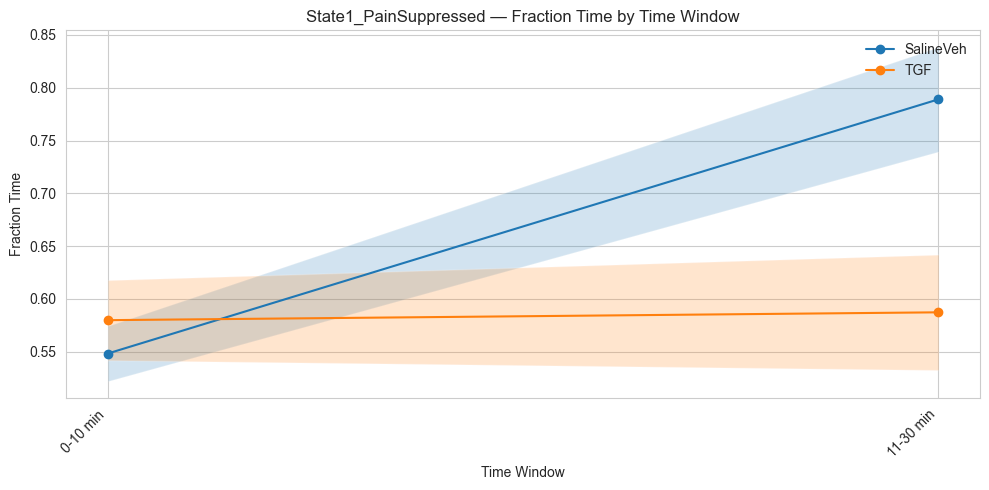

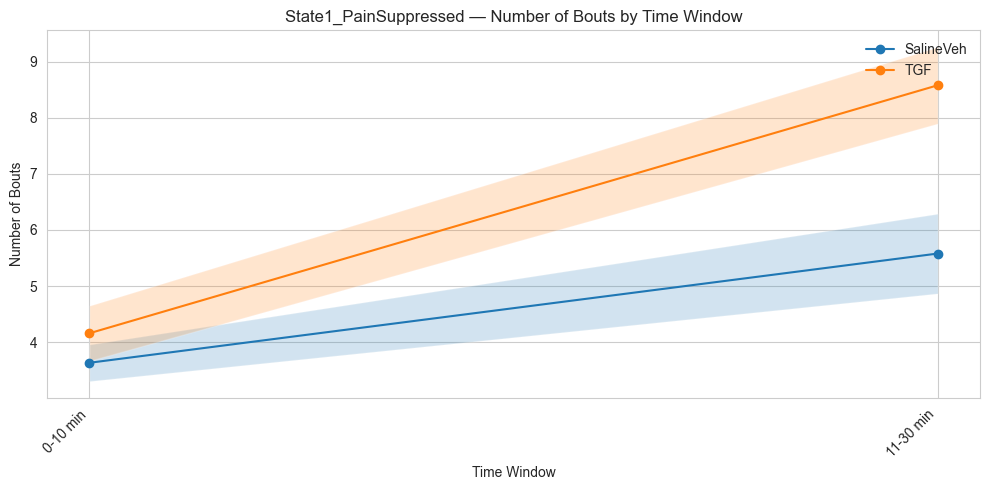

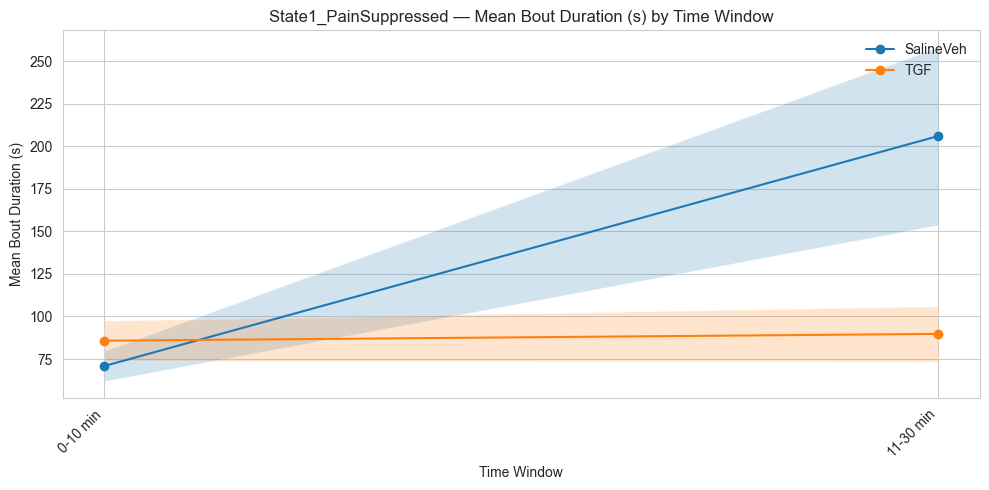

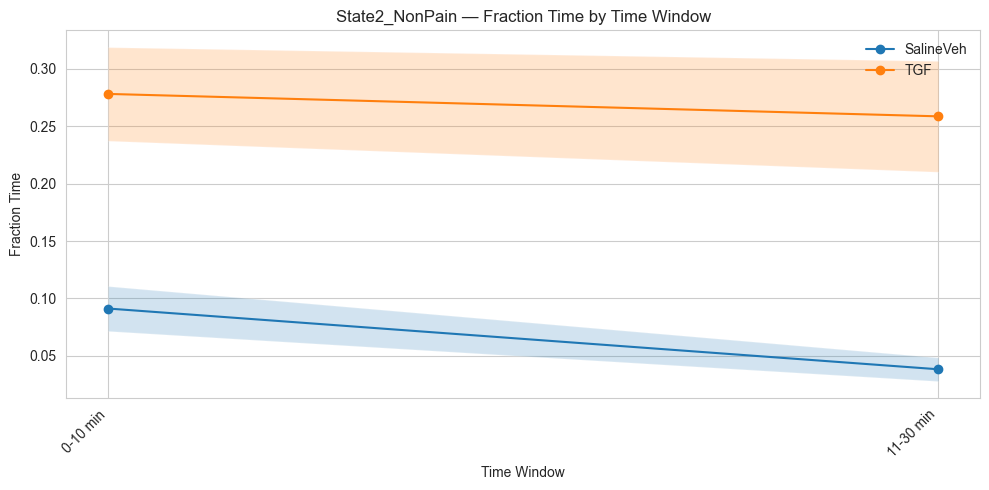

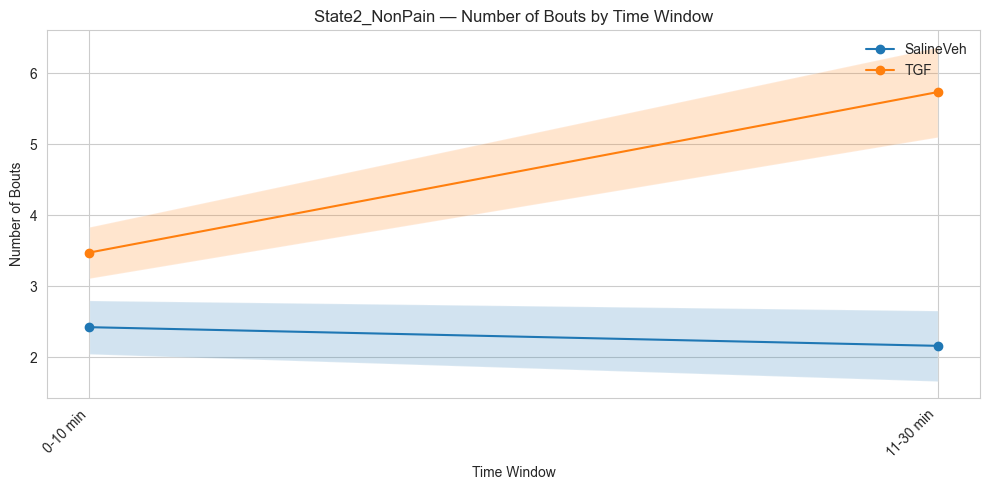

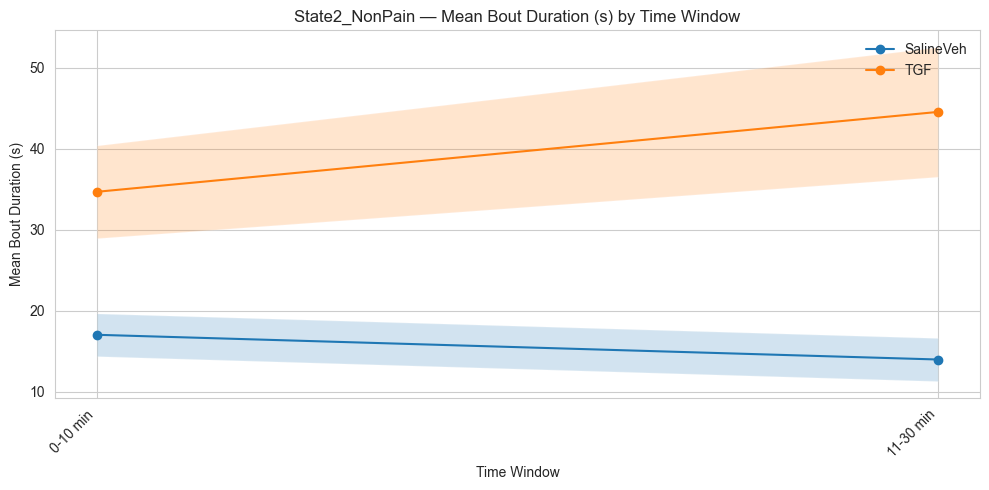

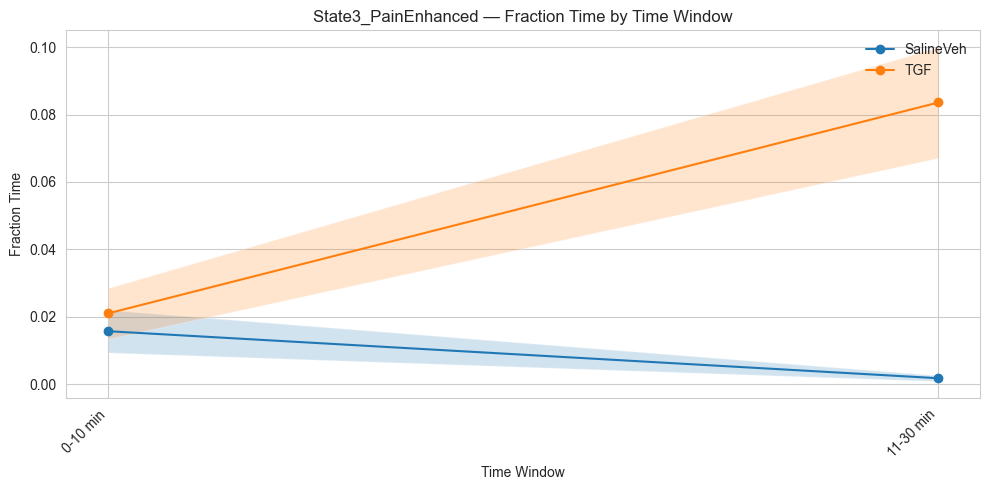

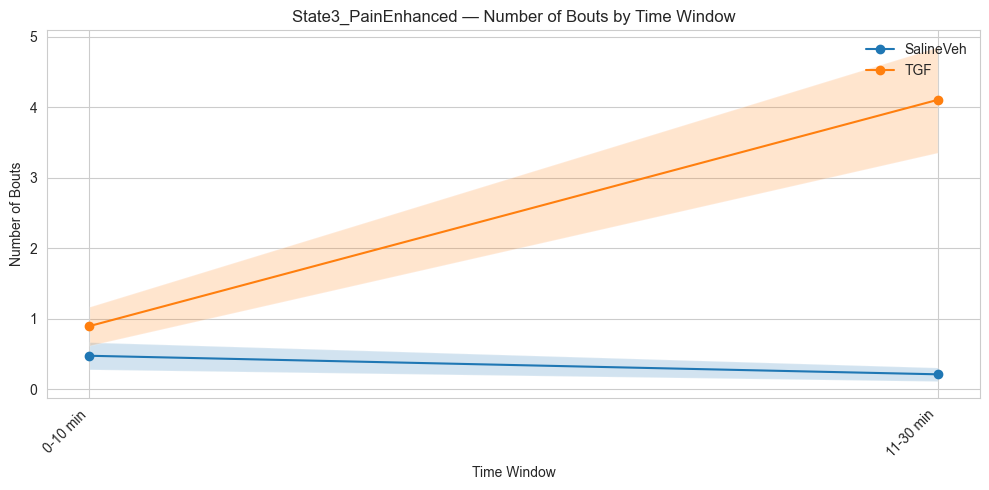

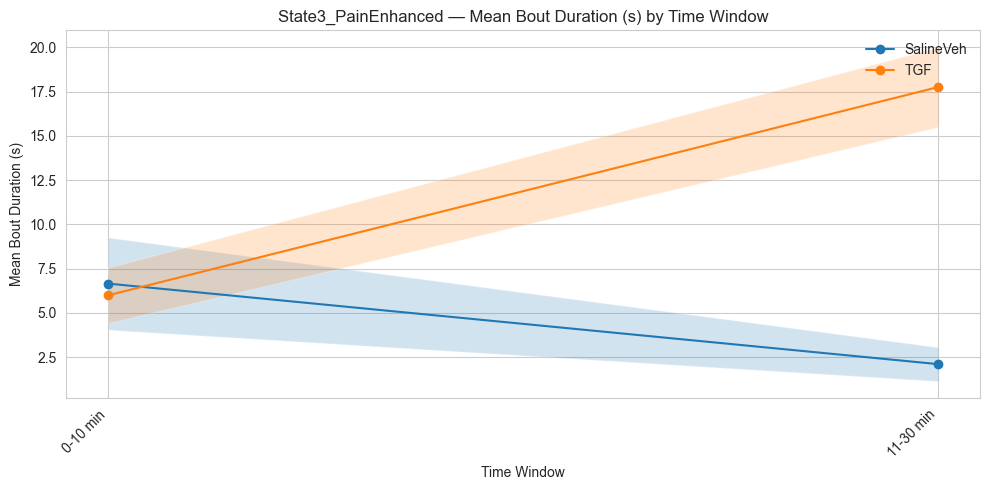

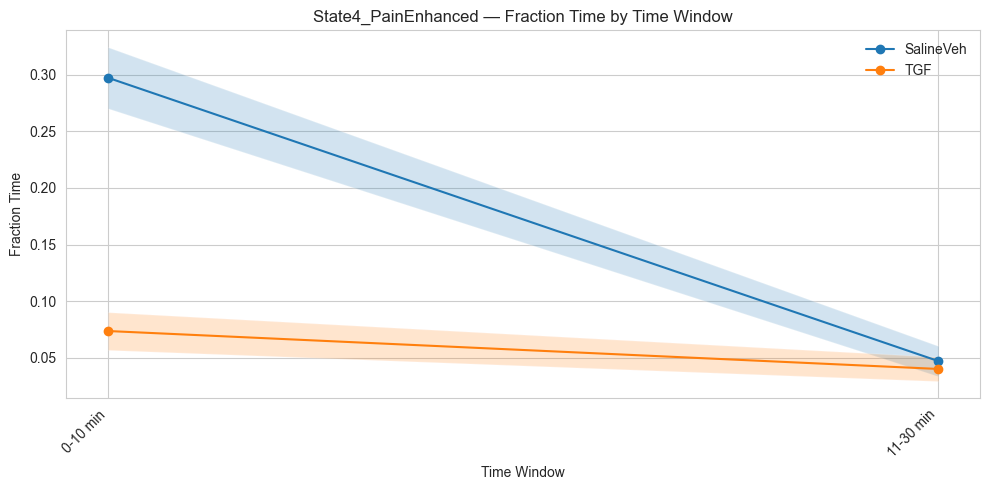

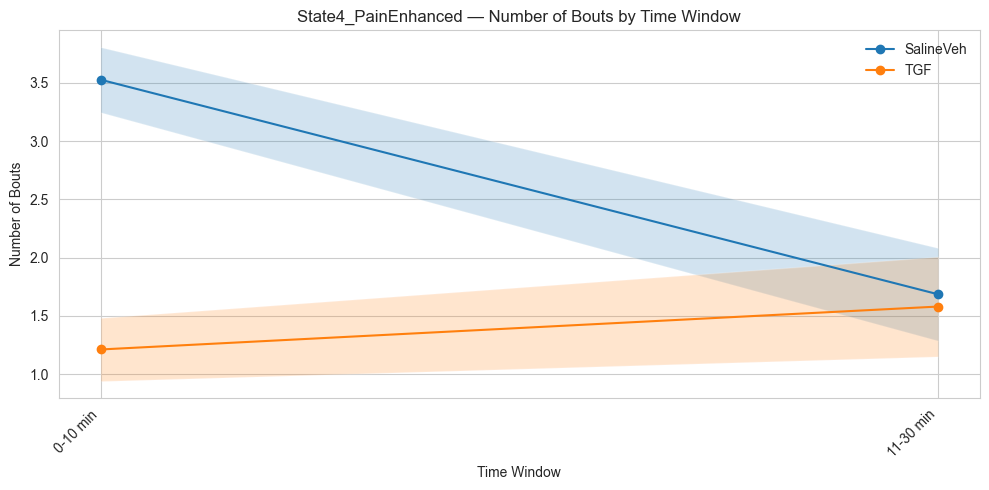

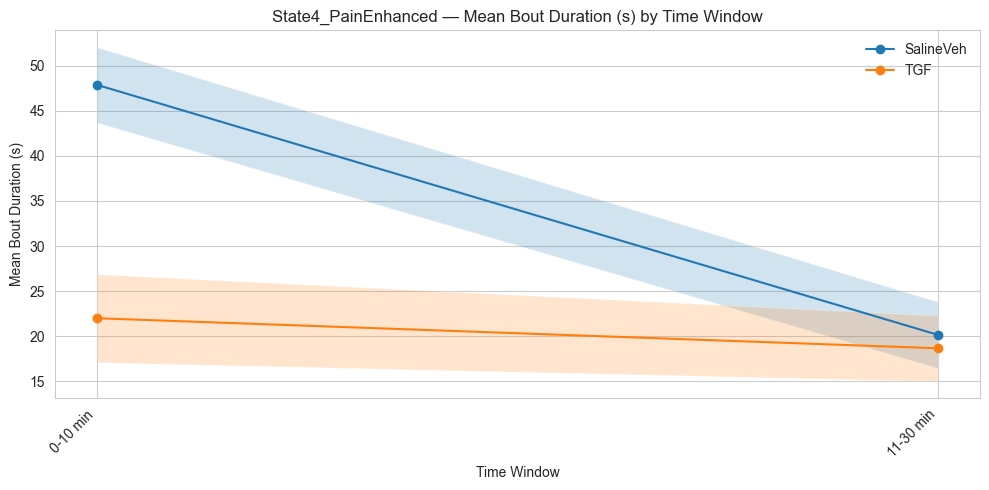

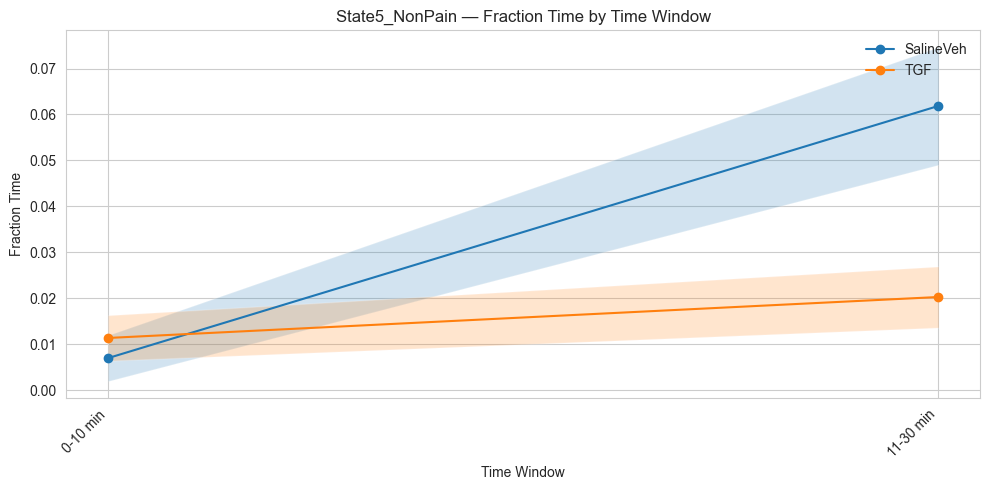

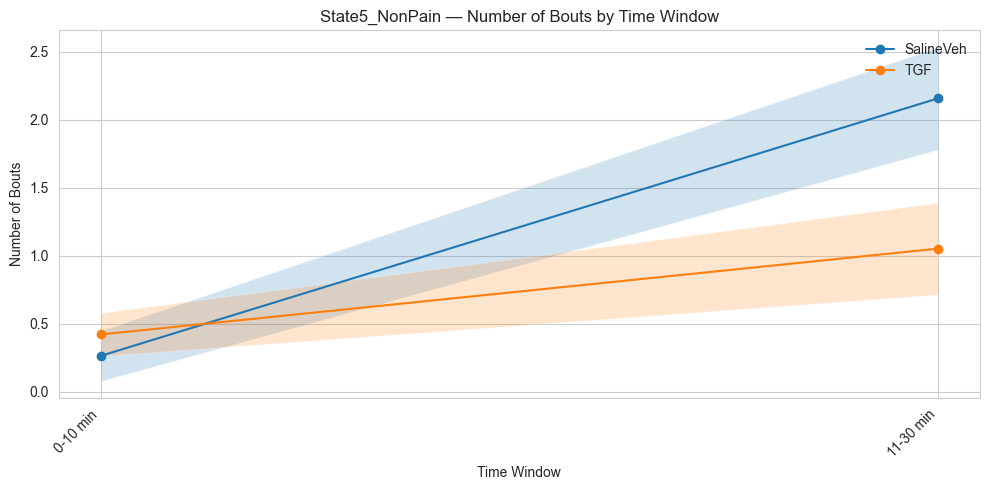

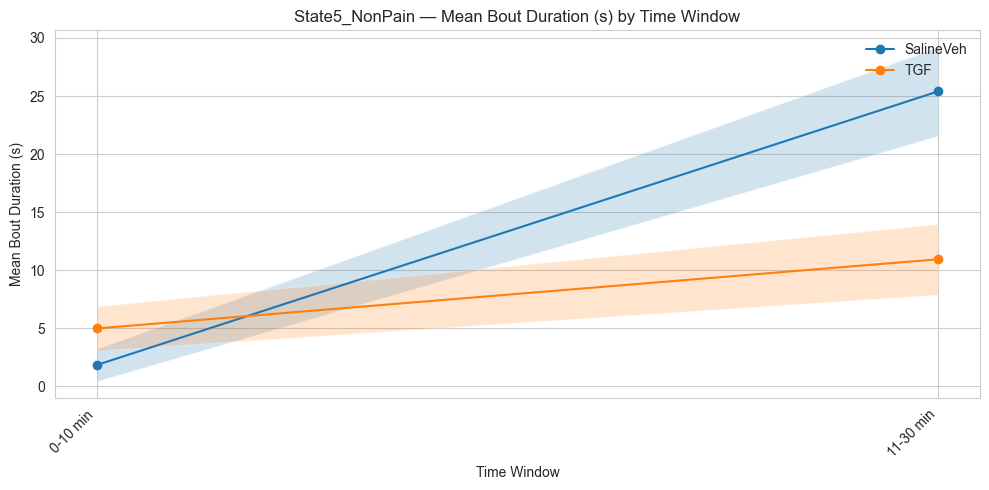

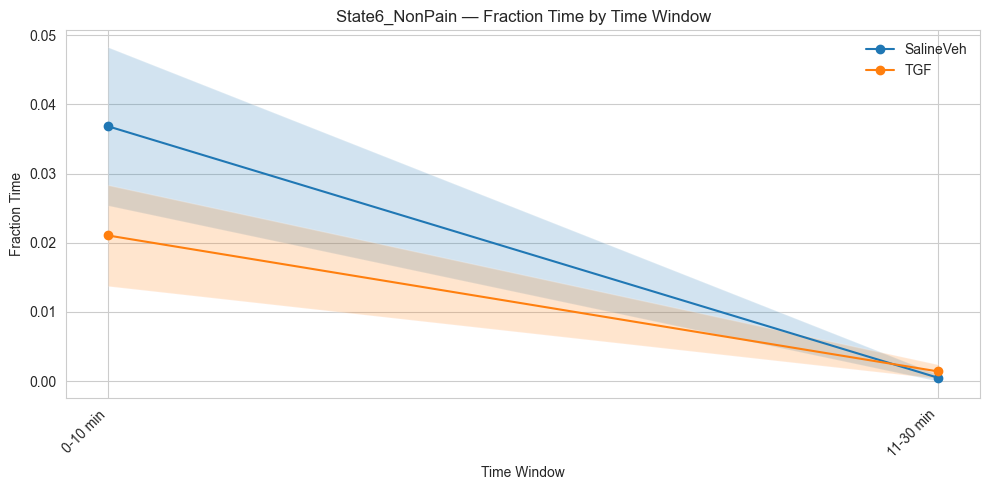

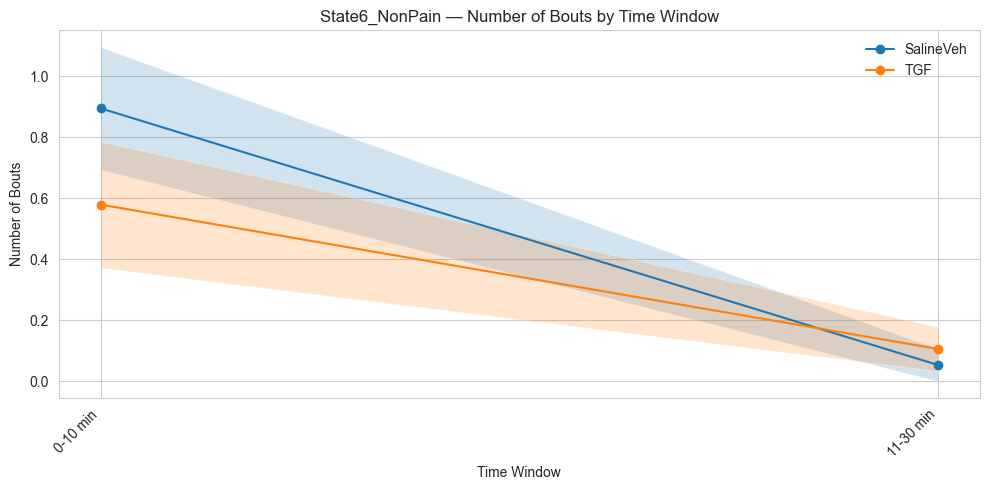

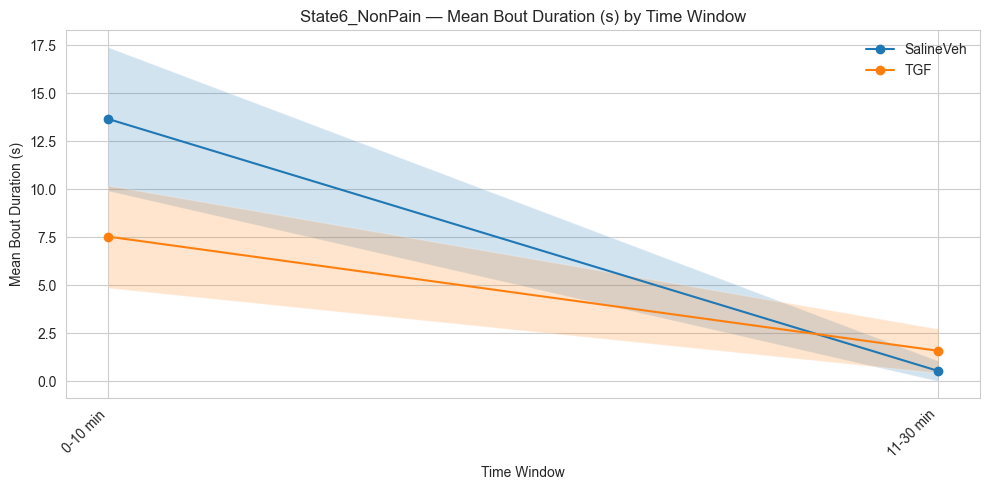

Timepoint state visualizations saved to: ../processed_dataset/project_Wisc_OpioidTGFSaline/figures/behaviors_LUPE-AMPS/Timepoint_Comparison/State_Viz


In [17]:
def calculate_state_statistics(behav_state, n_states, fps, min_frames):
    """Calculate fraction time, bout number, and bout duration for states."""
    n_animals = behav_state.shape[1]
    
    total_fraction_state = np.zeros((n_animals, n_states))
    n_bouts_state = np.zeros((n_animals, n_states))
    bout_duration_state = np.zeros((n_animals, n_states))
    
    for k in range(n_animals):
        data = behav_state[:, k]
        
        for b in range(1, n_states + 1):
            binary_data = (data == b).astype(int)
            
            if np.sum(binary_data) > 0:
                bout_starts, bout_ends = find_bouts(binary_data, min_frames)
                
                if len(bout_starts) > 0 and len(bout_ends) > 0:
                    bout_ends = bout_ends[bout_ends >= bout_starts[0]]
                    if len(bout_ends) > 0:
                        bout_starts = bout_starts[bout_starts <= bout_ends[-1]]
                    
                    if len(bout_starts) > 0 and len(bout_ends) > 0:
                        n_valid = min(len(bout_starts), len(bout_ends))
                        durations = (bout_ends[:n_valid] - bout_starts[:n_valid]) / fps
                        
                        total_fraction_state[k, b-1] = np.mean(binary_data)
                        n_bouts_state[k, b-1] = len(bout_starts)
                        bout_duration_state[k, b-1] = np.mean(durations) if len(durations) > 0 else 0
    
    return total_fraction_state, n_bouts_state, bout_duration_state

# Calculate state statistics
min_frames_state_true_positive = max(1, int(round((min_frames_true_positive / sampling_rate) * target_fps)))

total_fraction_state, n_bouts_state, bout_duration_state = calculate_state_statistics(
    behav_state, n_states, target_fps, min_frames_state_true_positive
)

print(f"State statistics calculated for {total_fraction_state.shape[0]} animals")

# Descriptive state column names (consistent with Section 6)
state_cols_descriptive = [
    state_column_names[i] for i in range(1, n_states + 1)
]

# Export state statistics
output_dir_section7 = os.path.join(output_base_dir, 'Section7_StateStats')
os.makedirs(output_dir_section7, exist_ok=True)

df_frac = pd.DataFrame(total_fraction_state, columns=state_cols_descriptive, index=animal_names)
df_frac['Group'] = group_labels
df_frac['Condition'] = condition_labels
df_frac.to_csv(os.path.join(output_dir_section7, f'{project_name}_state_fraction_time.csv'))

df_bouts = pd.DataFrame(n_bouts_state, columns=state_cols_descriptive, index=animal_names)
df_bouts['Group'] = group_labels
df_bouts['Condition'] = condition_labels
df_bouts.to_csv(os.path.join(output_dir_section7, f'{project_name}_state_bout_number.csv'))

df_dur = pd.DataFrame(bout_duration_state, columns=state_cols_descriptive, index=animal_names)
df_dur['Group'] = group_labels
df_dur['Condition'] = condition_labels
df_dur.to_csv(os.path.join(output_dir_section7, f'{project_name}_state_bout_duration.csv'))

print(f"State statistics exported to: {output_dir_section7}")

### Section 7b: TIMEPOINT COMPARISON — STATE STATS
# Computes state fraction time / bouts / mean duration within each time window.
state_timepoint_rows = []

for label, (start_min, end_min) in zip(time_labels, time_ranges_min):
    sl = _min_to_slice(start_min, end_min, target_fps, behav_state.shape[0])
    if sl.stop <= sl.start:
        print(f"Skipping empty window: {label}")
        continue

    behav_state_win = behav_state[sl, :]

    frac_s, bouts_s, dur_s = calculate_state_statistics(
        behav_state_win,
        n_states=n_states,
        fps=target_fps,
        min_frames=min_frames_state_true_positive
    )

    for a_idx, animal in enumerate(animal_names):
        for s_idx in range(n_states):
            state_name = state_column_names[s_idx + 1]
            state_timepoint_rows.append({
                'Time_Group': label,
                'Start_min': start_min,
                'End_min': end_min,
                'Animal': animal,
                'Group': group_labels[a_idx],
                'Condition': condition_labels[a_idx],
                'State': state_name,
                'FractionTime': float(frac_s[a_idx, s_idx]),
                'NumBouts': float(bouts_s[a_idx, s_idx]),
                'MeanDuration_s': float(dur_s[a_idx, s_idx])
            })

if len(state_timepoint_rows) > 0:
    df_state_timepoints = pd.DataFrame(state_timepoint_rows)
    df_state_timepoints.to_csv(
        os.path.join(output_dir_timepoints, f'{project_name}_state_timepoint_comparison.csv'),
        index=False
    )
    print(f"Timepoint state comparison saved to: {output_dir_timepoints}")
else:
    print("No timepoint state rows to export.")

### Section 7c: TIMEPOINT VISUALIZATION — STATE STATS (FIXED)
# FIXED: plot PER GROUP so condition labels correspond to selected_conditions within each selected_group.
# Also forces x-axis ordering to match time_labels (even if a window is missing).

if 'df_state_timepoints' in globals() and len(state_timepoint_rows) > 0:
    output_dir_timepoints_stateviz = os.path.join(output_dir_timepoints, 'State_Viz')
    os.makedirs(output_dir_timepoints_stateviz, exist_ok=True)

    metric_dirs = {
        'FractionTime': os.path.join(output_dir_timepoints_stateviz, 'FractionTime'),
        'NumBouts': os.path.join(output_dir_timepoints_stateviz, 'NumBouts'),
        'MeanDuration_s': os.path.join(output_dir_timepoints_stateviz, 'MeanDuration'),
    }
    for d in metric_dirs.values():
        os.makedirs(d, exist_ok=True)

    # enforce categorical ordering for x-axis
    df_state_timepoints['Time_Group'] = pd.Categorical(
        df_state_timepoints['Time_Group'],
        categories=time_labels,
        ordered=True
    )

    metrics_to_plot = [
        ('FractionTime', 'Fraction Time'),
        ('NumBouts', 'Number of Bouts'),
        ('MeanDuration_s', 'Mean Bout Duration (s)')
    ]

    def _sem(x):
        return x.std(ddof=1) / np.sqrt(len(x)) if len(x) > 1 else 0.0

    # IMPORTANT: preserve user-selected order
    unique_groups = list(selected_groups)
    unique_conditions = list(selected_conditions)
    unique_states = [state_column_names[i] for i in range(1, n_states + 1)]

    for st in unique_states:
        df_s = df_state_timepoints[df_state_timepoints['State'] == st].copy()
        if df_s.empty:
            continue

        # summary once
        summary = (
            df_s.groupby(['Group', 'Condition', 'Time_Group'], observed=True)
            .agg(
                mean_FractionTime=('FractionTime', 'mean'),
                sem_FractionTime=('FractionTime', _sem),
                mean_NumBouts=('NumBouts', 'mean'),
                sem_NumBouts=('NumBouts', _sem),
                mean_MeanDuration_s=('MeanDuration_s', 'mean'),
                sem_MeanDuration_s=('MeanDuration_s', _sem),
                n=('FractionTime', 'size'),
            )
            .reset_index()
        )

        # PLOT PER GROUP
        for group in unique_groups:
            summary_g = summary[summary['Group'] == group].copy()
            if summary_g.empty:
                continue

            for metric_key, metric_label in metrics_to_plot:
                mean_col = f"mean_{metric_key}"
                sem_col = f"sem_{metric_key}"

                plt.figure(figsize=(10, 5))

                for cond in unique_conditions:
                    sdf = summary_g[summary_g['Condition'] == cond].sort_values('Time_Group')
                    if sdf.empty:
                        continue

                    # align to full time_labels order (handles missing windows cleanly)
                    sdf = sdf.set_index('Time_Group').reindex(time_labels).reset_index()

                    x = np.arange(len(time_labels))
                    y = sdf[mean_col].to_numpy(dtype=float)
                    e = sdf[sem_col].to_numpy(dtype=float)

                    n_line = int(np.nanmax(sdf["n"].to_numpy(dtype=float))) if np.any(~np.isnan(sdf["n"])) else 0
                    line_label = f"{cond} (n={n_line})"

                    plt.plot(x, y, marker='o', label=line_label)
                    plt.fill_between(x, y - e, y + e, alpha=0.2)

                plt.xticks(np.arange(len(time_labels)), time_labels, rotation=45, ha='right')
                plt.xlabel('Time Window')
                plt.ylabel(metric_label)
                plt.title(f'{st} — {metric_label} by Time Window\nGroup: {group}')
                plt.legend(frameon=False)
                plt.tight_layout()

                fname = f"{project_name}_timepoint_{group}_{st}_{metric_key}".replace('/', '_').replace(' ', '_')
                plt.savefig(os.path.join(metric_dirs[metric_key], f"{fname}.png"), dpi=300)
                plt.savefig(os.path.join(metric_dirs[metric_key], f"{fname}.svg"))
                plt.show()

    print(f"Timepoint state visualizations saved to: {output_dir_timepoints_stateviz}")
else:
    print("Skipping Section 7c: df_state_timepoints not available or empty.")

### Section 8: STATE VISUALIZATION

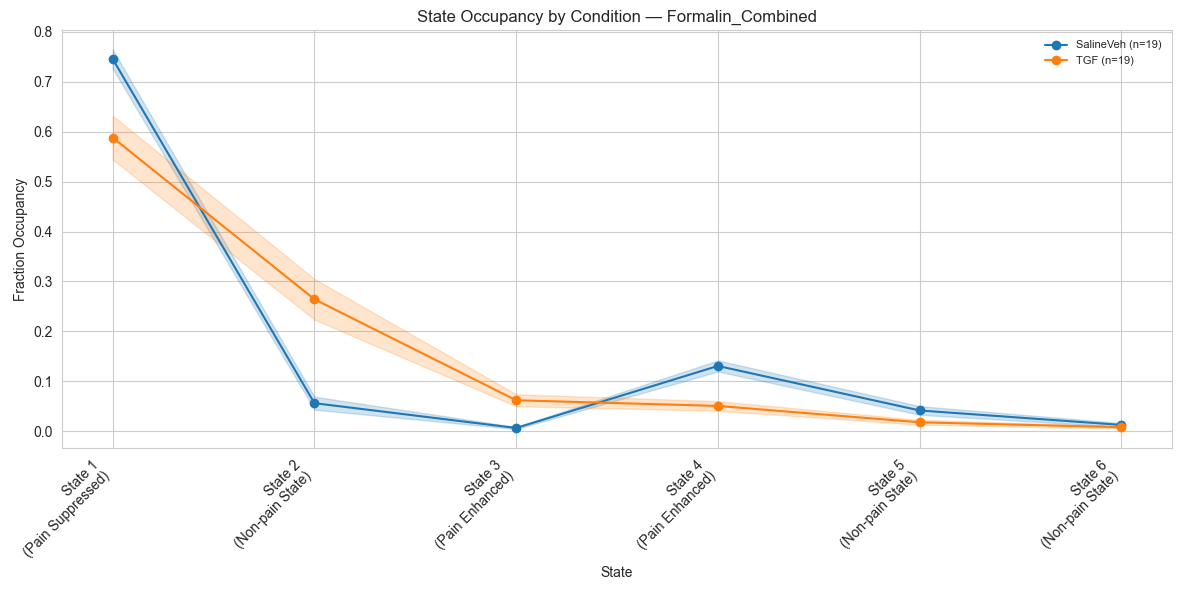

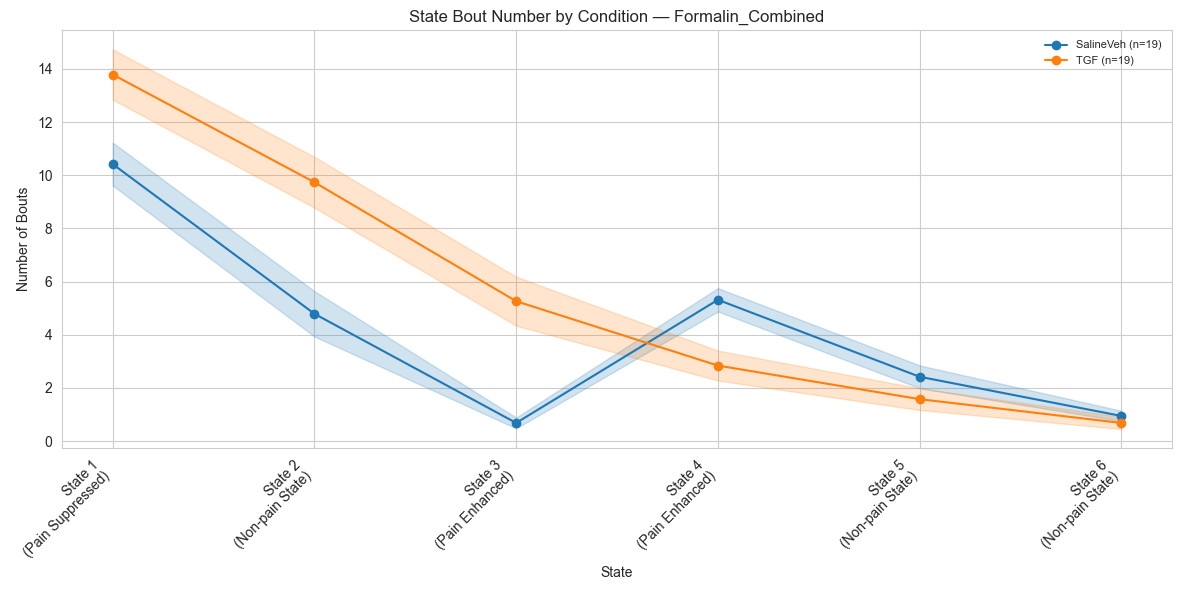

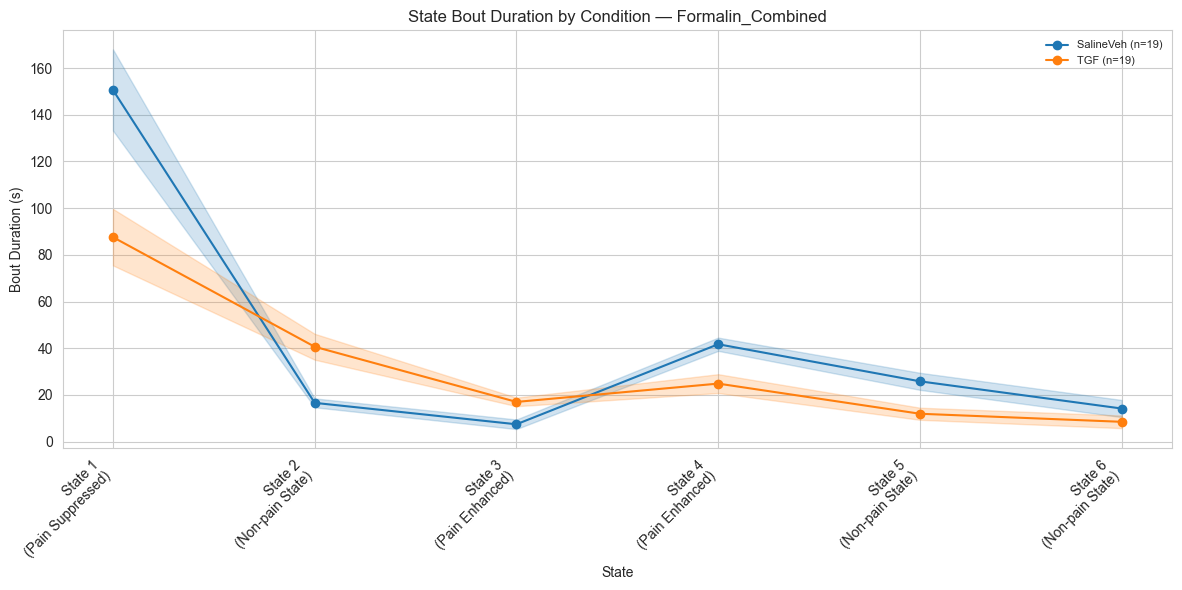

State visualizations saved to: ../processed_dataset/project_Wisc_OpioidTGFSaline/figures/behaviors_LUPE-AMPS/Section8_StateViz
Summary CSVs exported (include Group, Condition, State):
  - project_Wisc_OpioidTGFSaline_state_occupancy_summary.csv
  - project_Wisc_OpioidTGFSaline_state_bouts_summary.csv
  - project_Wisc_OpioidTGFSaline_state_duration_summary.csv
Per-group figures exported:
  - project_Wisc_OpioidTGFSaline_state_occupancy_line_{Group}.png/svg
  - project_Wisc_OpioidTGFSaline_state_bouts_line_{Group}.png/svg
  - project_Wisc_OpioidTGFSaline_state_duration_line_{Group}.png/svg


In [18]:
output_dir_section8 = os.path.join(output_base_dir, 'Section8_StateViz')
os.makedirs(output_dir_section8, exist_ok=True)

states_display = [f"State {i+1}\n({state_categories[i+1]})" for i in range(6)]

# 8a. State Occupancy by Condition (per group)
occupancy_summary = []

for group in unique_groups:
    fig, ax = plt.subplots(figsize=(12, 6))

    for cond in unique_conditions:
        mask = np.array([(g == group and c == cond) for g, c in zip(group_labels, condition_labels)])
        n_animals = int(np.sum(mask))

        if n_animals == 0:
            continue

        cond_data = total_fraction_state[mask, :]
        means = np.mean(cond_data, axis=0)
        sem = np.std(cond_data, axis=0, ddof=1) / np.sqrt(n_animals) if n_animals > 1 else np.zeros_like(means)

        x = np.arange(n_states)
        ax.plot(x, means, marker='o', label=f'{cond} (n={n_animals})', color=condition_colors[cond])
        ax.fill_between(x, means - sem, means + sem, alpha=0.2, color=condition_colors[cond])

        # Store for CSV (ONE State column only)
        for s in range(n_states):
            occupancy_summary.append({
                'Group': group,
                'Condition': cond,
                'State': state_column_names[s + 1],
                'Mean': means[s],
                'SEM': sem[s]
            })

    ax.set_xticks(range(n_states))
    ax.set_xticklabels(states_display, rotation=45, ha='right')
    ax.set_xlabel('State')
    ax.set_ylabel('Fraction Occupancy')
    ax.set_title(f'State Occupancy by Condition — {group}')
    ax.legend(fontsize=8, frameon=False)

    plt.tight_layout()
    plt.savefig(os.path.join(output_dir_section8, f'{project_name}_state_occupancy_line_{group}.png'), dpi=300)
    plt.savefig(os.path.join(output_dir_section8, f'{project_name}_state_occupancy_line_{group}.svg'))
    plt.show()

pd.DataFrame(occupancy_summary).to_csv(
    os.path.join(output_dir_section8, f'{project_name}_state_occupancy_summary.csv'),
    index=False
)

# 8b. Number of Bouts by Condition (per group)
bouts_summary = []

for group in unique_groups:
    fig, ax = plt.subplots(figsize=(12, 6))

    for cond in unique_conditions:
        mask = np.array([(g == group and c == cond) for g, c in zip(group_labels, condition_labels)])
        n_animals = int(np.sum(mask))

        if n_animals == 0:
            continue

        cond_data = n_bouts_state[mask, :]
        means = np.mean(cond_data, axis=0)
        sem = np.std(cond_data, axis=0, ddof=1) / np.sqrt(n_animals) if n_animals > 1 else np.zeros_like(means)

        x = np.arange(n_states)
        ax.plot(x, means, marker='o', label=f'{cond} (n={n_animals})', color=condition_colors[cond])
        ax.fill_between(x, means - sem, means + sem, alpha=0.2, color=condition_colors[cond])

        for s in range(n_states):
            bouts_summary.append({
                'Group': group,
                'Condition': cond,
                'State': state_column_names[s + 1],
                'Mean': means[s],
                'SEM': sem[s]
            })

    ax.set_xticks(range(n_states))
    ax.set_xticklabels(states_display, rotation=45, ha='right')
    ax.set_xlabel('State')
    ax.set_ylabel('Number of Bouts')
    ax.set_title(f'State Bout Number by Condition — {group}')
    ax.legend(fontsize=8, frameon=False)

    plt.tight_layout()
    plt.savefig(os.path.join(output_dir_section8, f'{project_name}_state_bouts_line_{group}.png'), dpi=300)
    plt.savefig(os.path.join(output_dir_section8, f'{project_name}_state_bouts_line_{group}.svg'))
    plt.show()

pd.DataFrame(bouts_summary).to_csv(
    os.path.join(output_dir_section8, f'{project_name}_state_bouts_summary.csv'),
    index=False
)

# 8c. Bout Duration by Condition (per group)
duration_summary = []

for group in unique_groups:
    fig, ax = plt.subplots(figsize=(12, 6))

    for cond in unique_conditions:
        mask = np.array([(g == group and c == cond) for g, c in zip(group_labels, condition_labels)])
        n_animals = int(np.sum(mask))

        if n_animals == 0:
            continue

        cond_data = bout_duration_state[mask, :]
        means = np.mean(cond_data, axis=0)
        sem = np.std(cond_data, axis=0, ddof=1) / np.sqrt(n_animals) if n_animals > 1 else np.zeros_like(means)

        x = np.arange(n_states)
        ax.plot(x, means, marker='o', label=f'{cond} (n={n_animals})', color=condition_colors[cond])
        ax.fill_between(x, means - sem, means + sem, alpha=0.2, color=condition_colors[cond])

        for s in range(n_states):
            duration_summary.append({
                'Group': group,
                'Condition': cond,
                'State': state_column_names[s + 1],
                'Mean': means[s],
                'SEM': sem[s]
            })

    ax.set_xticks(range(n_states))
    ax.set_xticklabels(states_display, rotation=45, ha='right')
    ax.set_xlabel('State')
    ax.set_ylabel('Bout Duration (s)')
    ax.set_title(f'State Bout Duration by Condition — {group}')
    ax.legend(fontsize=8, frameon=False)

    plt.tight_layout()
    plt.savefig(os.path.join(output_dir_section8, f'{project_name}_state_duration_line_{group}.png'), dpi=300)
    plt.savefig(os.path.join(output_dir_section8, f'{project_name}_state_duration_line_{group}.svg'))
    plt.show()

pd.DataFrame(duration_summary).to_csv(
    os.path.join(output_dir_section8, f'{project_name}_state_duration_summary.csv'),
    index=False
)

print(f"State visualizations saved to: {output_dir_section8}")
print(f"Summary CSVs exported (include Group, Condition, State):")
print(f"  - {project_name}_state_occupancy_summary.csv")
print(f"  - {project_name}_state_bouts_summary.csv")
print(f"  - {project_name}_state_duration_summary.csv")
print(f"Per-group figures exported:")
print(f"  - {project_name}_state_occupancy_line_{{Group}}.png/svg")
print(f"  - {project_name}_state_bouts_line_{{Group}}.png/svg")
print(f"  - {project_name}_state_duration_line_{{Group}}.png/svg")

### Section 9: PCA PROJECTION - AMPS CALCULATION

Loading PCA parameters from: ../model/pain_scale_params.mat
PCA coeff shape: (6, 6)
PCA mean shape: (6,)

AMPS Scores Calculated:
  General Behavior Scale (PC1) range: [-0.501, 0.329]
  AMPS (PC2) range: [-0.334, 0.113]


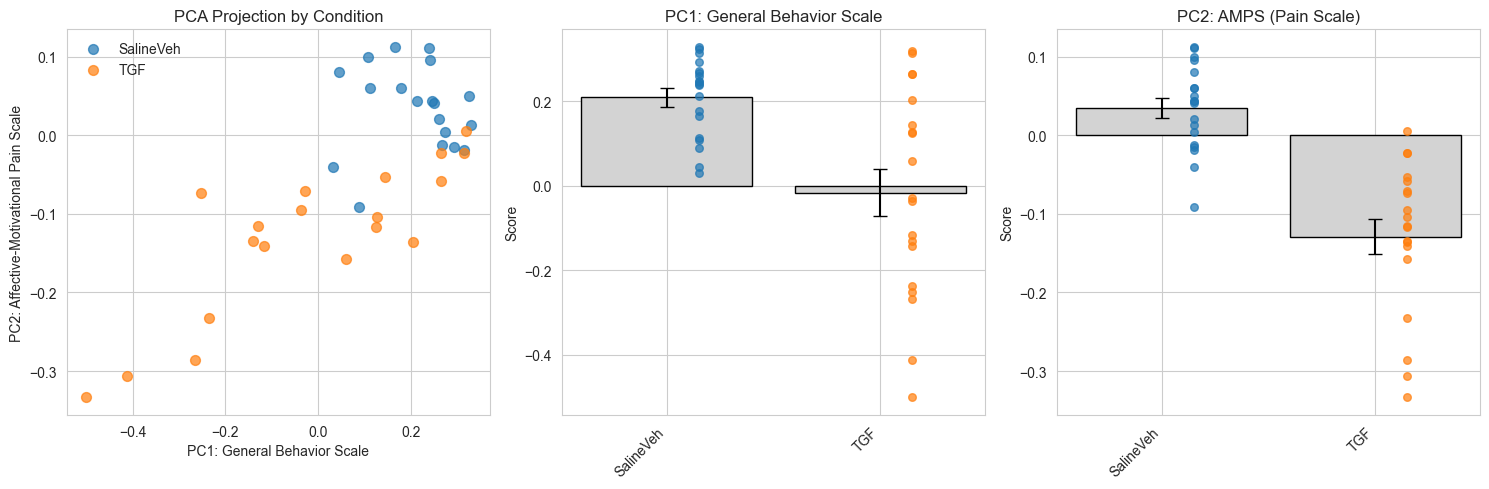

Timepoint AMPS comparison saved to: ../processed_dataset/project_Wisc_OpioidTGFSaline/figures/behaviors_LUPE-AMPS/Timepoint_Comparison


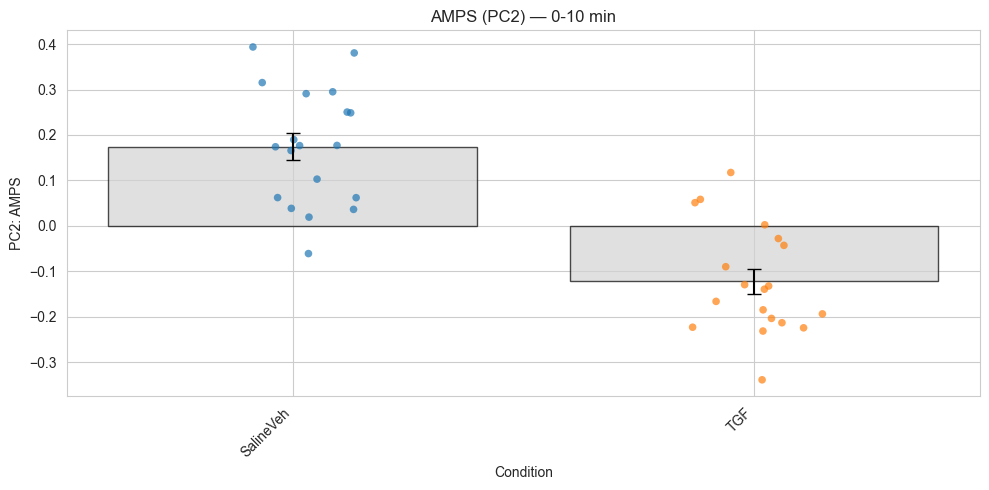

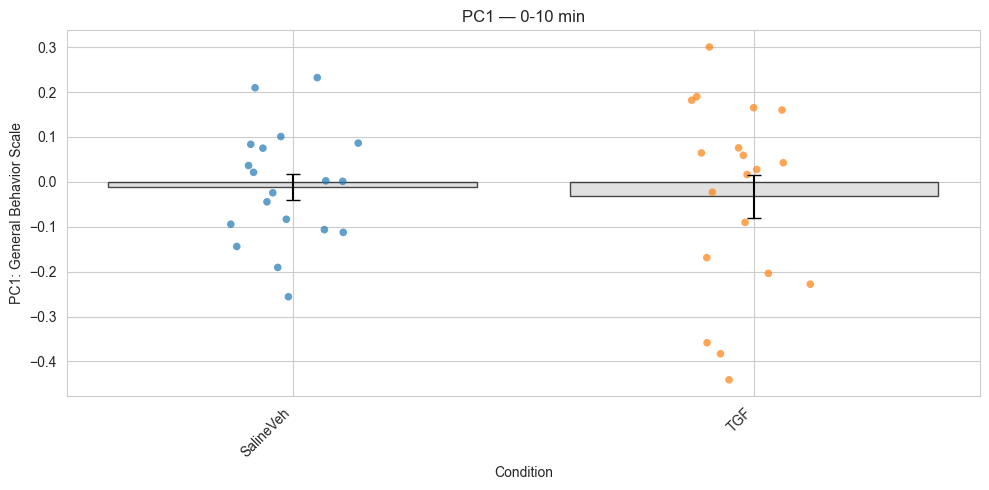

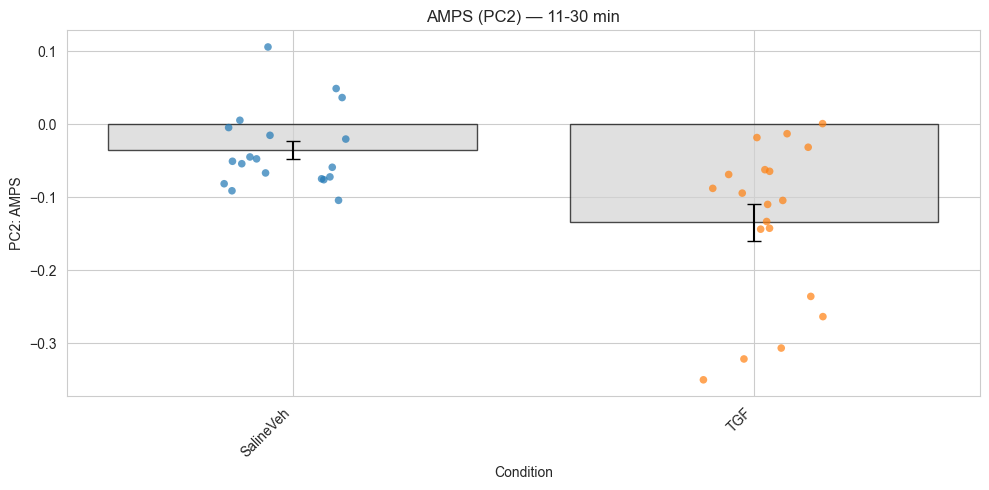

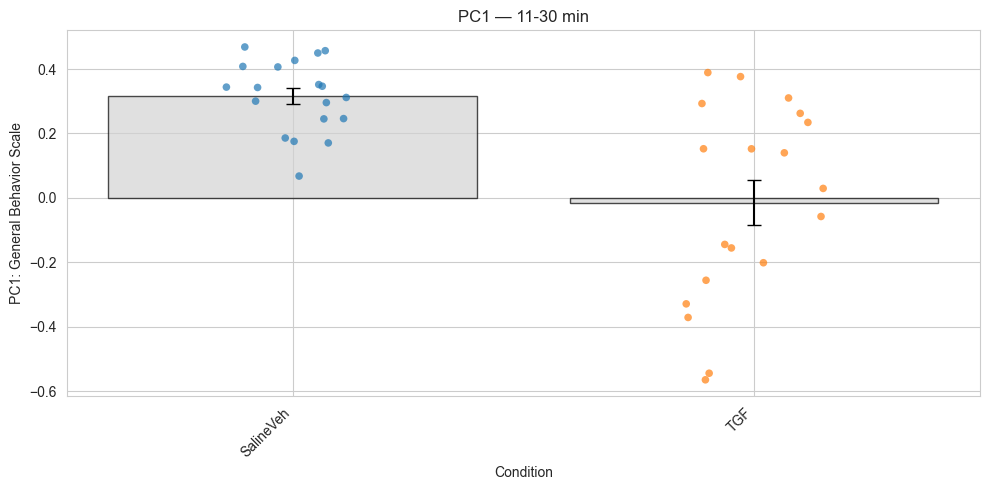

Timepoint AMPS bar-plot visualizations saved to: ../processed_dataset/project_Wisc_OpioidTGFSaline/figures/behaviors_LUPE-AMPS/Timepoint_Comparison/AMPS_Viz

AMPS results saved to: ../processed_dataset/project_Wisc_OpioidTGFSaline/figures/behaviors_LUPE-AMPS/Section9_AMPS


In [23]:
def load_pca_params(pca_path):
    """Load PCA parameters (coeff/loadings and mean) from .pkl or .mat.

    Returns:
        coeff: (n_features, n_components) array
        mu:    (n_features,) array

    Notes:
    - For sklearn PCA objects: components_ is (n_components, n_features) so we transpose.
    - For MATLAB exports we support:
        * pain_scale_params struct containing coeff and mu
        * direct variables coeff and mu
    - We defensively squeeze/reshape to ensure coeff is 2D and mu is 1D.
    """
    if not isinstance(pca_path, str):
        raise TypeError(f"pca_path must be a string, got {type(pca_path)}")

    if pca_path.endswith('.pkl'):
        with open(pca_path, 'rb') as f:
            data = pickle.load(f)

        # sklearn PCA object
        if hasattr(data, 'components_') and hasattr(data, 'mean_'):
            coeff = np.asarray(data.components_).T
            mu = np.asarray(data.mean_).squeeze()
            return coeff, mu

        if isinstance(data, dict):
            # common key variants
            coeff = data.get('coeff', None)
            if coeff is None:
                coeff = data.get('components_', None)
            mu = data.get('mu', None)
            if mu is None:
                mu = data.get('mean_', None)

            if coeff is None:
                raise KeyError("PCA .pkl dict missing 'coeff'/'components_' key")
            if mu is None:
                coeff_arr = np.asarray(coeff)
                n_features = coeff_arr.shape[-1] if coeff_arr.ndim == 2 else int(coeff_arr.size)
                mu = np.zeros(n_features)

            coeff = np.asarray(coeff)
            mu = np.asarray(mu).squeeze()

            if coeff.ndim != 2:
                raise ValueError(f"PCA coeff must be 2D, got shape {coeff.shape}")

            if mu.ndim == 1 and coeff.shape[0] != mu.shape[0] and coeff.shape[1] == mu.shape[0]:
                coeff = coeff.T

            if mu.ndim != 1:
                mu = mu.reshape(-1)
            if coeff.shape[0] != mu.shape[0]:
                raise ValueError(f"Shape mismatch: coeff {coeff.shape} vs mu {mu.shape}")

            return coeff, mu

        raise ValueError("Unrecognized PCA format in .pkl")

    if pca_path.endswith('.mat'):
        from scipy.io import loadmat
        data = loadmat(pca_path)

        # Handle MATLAB struct format (pain_scale_params.coeff, pain_scale_params.mu)
        if 'pain_scale_params' in data:
            params = data['pain_scale_params']
            try:
                coeff = np.asarray(params['coeff'][0, 0])
            except Exception:
                coeff = np.asarray(params['coeff']).squeeze()
            try:
                mu = np.asarray(params['mu'][0, 0]).squeeze()
            except Exception:
                mu = np.asarray(params['mu']).squeeze()

            # Ensure shapes
            if mu.ndim != 1:
                mu = mu.reshape(-1)
            if coeff.ndim != 2:
                raise ValueError(f"PCA coeff must be 2D, got shape {coeff.shape}")

            # If coeff is (n_components, n_features), transpose
            if coeff.shape[0] != mu.shape[0] and coeff.shape[1] == mu.shape[0]:
                coeff = coeff.T

            if coeff.shape[0] != mu.shape[0]:
                raise ValueError(f"Shape mismatch: coeff {coeff.shape} vs mu {mu.shape}")

            return coeff, mu

        # Handle direct variable format (coeff, mu as separate variables)
        if 'coeff' in data and ('mu' in data or 'mean' in data):
            coeff = np.asarray(data['coeff']).squeeze()
            mu = np.asarray(data['mu'] if 'mu' in data else data['mean']).squeeze()

            if mu.ndim != 1:
                mu = mu.reshape(-1)
            if coeff.ndim != 2:
                raise ValueError(f"PCA coeff must be 2D, got shape {coeff.shape}")

            if coeff.shape[0] != mu.shape[0] and coeff.shape[1] == mu.shape[0]:
                coeff = coeff.T

            if coeff.shape[0] != mu.shape[0]:
                raise ValueError(f"Shape mismatch: coeff {coeff.shape} vs mu {mu.shape}")

            return coeff, mu

        keys = [k for k in data.keys() if not k.startswith('__')]
        raise KeyError(f"Could not find PCA params in .mat file. Keys: {keys}")

    raise ValueError(f"Unsupported file format: {pca_path}")


def project_to_pc_space(state_occupancy, coeff, mu):
    """Project state occupancy data into PC space.

    Args:
        state_occupancy: (n_samples, n_features)
        coeff:           (n_features, n_components)
        mu:              (n_features,)

    Returns:
        projected: (n_samples, 2) for PC1/PC2
    """
    occ = np.asarray(state_occupancy, dtype=float)
    coeff = np.asarray(coeff, dtype=float)
    mu = np.asarray(mu, dtype=float).reshape(-1)

    if occ.ndim != 2:
        raise ValueError(f"state_occupancy must be 2D, got shape {occ.shape}")
    if coeff.ndim != 2:
        raise ValueError(f"coeff must be 2D, got shape {coeff.shape}")
    if mu.ndim != 1:
        raise ValueError(f"mu must be 1D, got shape {mu.shape}")
    if occ.shape[1] != mu.shape[0]:
        raise ValueError(f"Shape mismatch: occupancy {occ.shape} vs mu {mu.shape}")
    if coeff.shape[0] != mu.shape[0]:
        raise ValueError(f"Shape mismatch: coeff {coeff.shape} vs mu {mu.shape}")

    centered = occ - mu
    projected = centered @ coeff[:, :2]
    return projected

# Load PCA parameters
print(f"Loading PCA parameters from: {pca_model_path}")
try:
    pca_coeff, pca_mu = load_pca_params(pca_model_path)
    print(f"PCA coeff shape: {pca_coeff.shape}")
    print(f"PCA mean shape: {pca_mu.shape}")
except Exception as e:
    print(f"Error loading PCA params: {e}")
    print("Fitting PCA on current data...")
    from sklearn.decomposition import PCA
    pca = PCA(n_components=2)
    pca.fit(total_fraction_state)
    pca_coeff = pca.components_.T
    pca_mu = pca.mean_

# Project to PC space
pca_projection = project_to_pc_space(total_fraction_state, pca_coeff, pca_mu)
general_behavior_scale = pca_projection[:, 0]  # PC1
amps = pca_projection[:, 1]  # PC2 - Affective-Motivational Pain Scale

print(f"\nAMPS Scores Calculated:")
print(f"  General Behavior Scale (PC1) range: [{general_behavior_scale.min():.3f}, {general_behavior_scale.max():.3f}]")
print(f"  AMPS (PC2) range: [{amps.min():.3f}, {amps.max():.3f}]")

# Export AMPS scores
output_dir_section9 = os.path.join(output_base_dir, 'Section9_AMPS')
os.makedirs(output_dir_section9, exist_ok=True)

df_amps = pd.DataFrame({
    'Animal': animal_names,
    'Group': group_labels,
    'Condition': condition_labels,
    'PC1_GeneralBehaviorScale': general_behavior_scale,
    'PC2_AMPS': amps
})
df_amps.to_csv(os.path.join(output_dir_section9, f'{project_name}_amps_scores.csv'), index=False)

# COHORT FIGURE (SHOW FIRST)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 9a) Scatter by condition
ax = axes[0]
for cond in unique_conditions:
    mask = np.array([c == cond for c in condition_labels])
    ax.scatter(
        general_behavior_scale[mask],
        amps[mask],
        c=[condition_colors[cond]],
        label=cond,
        s=50,
        alpha=0.7
    )
ax.set_xlabel('PC1: General Behavior Scale')
ax.set_ylabel('PC2: Affective-Motivational Pain Scale')
ax.set_title('PCA Projection by Condition')
ax.legend(frameon=False)

# 9a) Bar plot for PC1
ax = axes[1]
means, sems = [], []
for cond in unique_conditions:
    mask = np.array([c == cond for c in condition_labels])
    data = general_behavior_scale[mask]
    means.append(np.mean(data))
    sems.append(np.std(data, ddof=1) / np.sqrt(len(data)) if len(data) > 1 else 0.0)

x = np.arange(len(unique_conditions))
ax.bar(x, means, yerr=sems, capsize=5, color='lightgray', edgecolor='black')
for i, cond in enumerate(unique_conditions):
    mask = np.array([c == cond for c in condition_labels])
    data = general_behavior_scale[mask]
    ax.scatter(np.ones(len(data)) * i + 0.15, data, c=[condition_colors[cond]], s=30, alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(unique_conditions, rotation=45, ha='right')
ax.set_ylabel('Score')
ax.set_title('PC1: General Behavior Scale')

# 9a) Bar plot for AMPS (PC2)
ax = axes[2]
means, sems = [], []
for cond in unique_conditions:
    mask = np.array([c == cond for c in condition_labels])
    data = amps[mask]
    means.append(np.mean(data))
    sems.append(np.std(data, ddof=1) / np.sqrt(len(data)) if len(data) > 1 else 0.0)

x = np.arange(len(unique_conditions))
ax.bar(x, means, yerr=sems, capsize=5, color='lightgray', edgecolor='black')
for i, cond in enumerate(unique_conditions):
    mask = np.array([c == cond for c in condition_labels])
    data = amps[mask]
    ax.scatter(np.ones(len(data)) * i + 0.15, data, c=[condition_colors[cond]], s=30, alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(unique_conditions, rotation=45, ha='right')
ax.set_ylabel('Score')
ax.set_title('PC2: AMPS (Pain Scale)')

# Save + show cohort figure NOW (before timepoint plotting)
fig.tight_layout()
fig.savefig(os.path.join(output_dir_section9, f'{project_name}_amps_projection.png'), dpi=300)
fig.savefig(os.path.join(output_dir_section9, f'{project_name}_amps_projection.svg'))
plt.show()
plt.close(fig)  # <- important for some PyCharm backends

### Section 9b (OPTIONAL): TIMEPOINT COMPARISON — AMPS / PC1
# Recompute state occupancy within each time window, then project to PC space.
amps_timepoint_rows = []

for label, (start_min, end_min) in zip(time_labels, time_ranges_min):
    sl = _min_to_slice(start_min, end_min, target_fps, behav_state.shape[0])
    if sl.stop <= sl.start:
        print(f"Skipping empty window: {label}")
        continue

    behav_state_win = behav_state[sl, :]

    # State occupancy per animal (n_animals x 6)
    occ = np.zeros((behav_state_win.shape[1], n_states))
    for s in range(1, n_states + 1):
        occ[:, s - 1] = np.mean(behav_state_win == s, axis=0)

    proj = project_to_pc_space(occ, pca_coeff, pca_mu)
    pc1_win = proj[:, 0]
    pc2_win = proj[:, 1]

    for a_idx, animal in enumerate(animal_names):
        amps_timepoint_rows.append({
            'Time_Group': label,
            'Start_min': start_min,
            'End_min': end_min,
            'Animal': animal,
            'Group': group_labels[a_idx],
            'Condition': condition_labels[a_idx],
            'PC1_GeneralBehaviorScale': float(pc1_win[a_idx]),
            'PC2_AMPS': float(pc2_win[a_idx])
        })

if len(amps_timepoint_rows) > 0:
    df_amps_timepoints = pd.DataFrame(amps_timepoint_rows)
    df_amps_timepoints.to_csv(
        os.path.join(output_dir_timepoints, f'{project_name}_amps_timepoint_comparison.csv'),
        index=False
    )
    print(f"Timepoint AMPS comparison saved to: {output_dir_timepoints}")
else:
    print("No timepoint AMPS rows to export.")

# BAR PLOTS (by condition) for each time window, with individual points.
if 'df_amps_timepoints' in globals() and len(amps_timepoint_rows) > 0:
    output_dir_timepoints_ampsviz = os.path.join(output_dir_timepoints, 'AMPS_Viz')
    os.makedirs(output_dir_timepoints_ampsviz, exist_ok=True)

    # Subfolders by metric
    metric_dirs = {
        'PC2_AMPS': os.path.join(output_dir_timepoints_ampsviz, 'AMPS_PC2'),
        'PC1_GeneralBehaviorScale': os.path.join(output_dir_timepoints_ampsviz, 'PC1'),
    }
    for d in metric_dirs.values():
        os.makedirs(d, exist_ok=True)

    # Ensure time window order
    df_amps_timepoints['Time_Group'] = pd.Categorical(
        df_amps_timepoints['Time_Group'],
        categories=time_labels,
        ordered=True
    )

    def _sem(vals):
        vals = np.asarray(vals, dtype=float)
        return np.std(vals, ddof=1) / np.sqrt(len(vals)) if len(vals) > 1 else 0.0

    def _plot_bar_timewindow(df_win, value_col, ylab, title, out_dir, fname_suffix):
        if df_win is None or df_win.empty:
            return

        conds = list(unique_conditions)  # preserve your sorted ordering
        means, sems = [], []

        for cond in conds:
            vals = df_win.loc[df_win['Condition'] == cond, value_col].astype(float).values
            means.append(np.mean(vals) if len(vals) else np.nan)
            sems.append(_sem(vals) if len(vals) else 0.0)

        x = np.arange(len(conds))

        plt.figure(figsize=(10, 5))
        plt.bar(x, means, yerr=sems, capsize=5, color='lightgray', edgecolor='black', alpha=0.7)

        # overlay individual points with jitter
        for i, cond in enumerate(conds):
            vals = df_win.loc[df_win['Condition'] == cond, value_col].astype(float).values
            if len(vals) == 0:
                continue
            jitter = np.random.uniform(-0.15, 0.15, size=len(vals))
            plt.scatter(
                np.ones(len(vals)) * i + jitter,
                vals,
                c=[condition_colors[cond]],
                s=30,
                alpha=0.7,
                edgecolors='none'
            )

        plt.xticks(x, conds, rotation=45, ha='right')
        plt.xlabel('Condition')
        plt.ylabel(ylab)
        plt.title(title)
        plt.tight_layout()

        fname = f"{project_name}_timepoint_{fname_suffix}".replace('/', '_').replace(' ', '_').replace('-', '_')
        plt.savefig(os.path.join(out_dir, f"{fname}.png"), dpi=300)
        plt.savefig(os.path.join(out_dir, f"{fname}.svg"))
        plt.show()

    for tg in time_labels:
        df_win = df_amps_timepoints[df_amps_timepoints['Time_Group'] == tg].copy()
        if df_win.empty:
            continue

        _plot_bar_timewindow(
            df_win,
            value_col='PC2_AMPS',
            ylab='PC2: AMPS',
            title=f"AMPS (PC2) — {tg}",
            out_dir=metric_dirs['PC2_AMPS'],
            fname_suffix=f"AMPS_PC2_{tg}"
        )

        _plot_bar_timewindow(
            df_win,
            value_col='PC1_GeneralBehaviorScale',
            ylab='PC1: General Behavior Scale',
            title=f"PC1 — {tg}",
            out_dir=metric_dirs['PC1_GeneralBehaviorScale'],
            fname_suffix=f"PC1_{tg}"
        )

    print(f"Timepoint AMPS bar-plot visualizations saved to: {output_dir_timepoints_ampsviz}")
else:
    print("Skipping Section 9c: df_amps_timepoints not available or empty.")

# Scatter by condition
ax = axes[0]
for cond in unique_conditions:
    mask = np.array([c == cond for c in condition_labels])
    ax.scatter(
        general_behavior_scale[mask], 
        amps[mask],
        c=[condition_colors[cond]],
        label=cond,
        s=50,
        alpha=0.7
    )
ax.set_xlabel('PC1: General Behavior Scale')
ax.set_ylabel('PC2: Affective-Motivational Pain Scale')
ax.set_title('PCA Projection by Condition')
ax.legend()

# Bar plot for PC1
ax = axes[1]
means = []
sems = []
for cond in unique_conditions:
    mask = np.array([c == cond for c in condition_labels])
    data = general_behavior_scale[mask]
    means.append(np.mean(data))
    sems.append(np.std(data, ddof=1) / np.sqrt(len(data)) if len(data) > 1 else 0.0)

x = np.arange(len(unique_conditions))
ax.bar(x, means, yerr=sems, capsize=5, color='lightgray', edgecolor='black')
for i, cond in enumerate(unique_conditions):
    mask = np.array([c == cond for c in condition_labels])
    data = general_behavior_scale[mask]
    ax.scatter(np.ones(len(data)) * i + 0.15, data, c=[condition_colors[cond]], s=30, alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(unique_conditions, rotation=45, ha='right')
ax.set_ylabel('Score')
ax.set_title('PC1: General Behavior Scale')

# Bar plot for AMPS
ax = axes[2]
means = []
sems = []
for cond in unique_conditions:
    mask = np.array([c == cond for c in condition_labels])
    data = amps[mask]
    means.append(np.mean(data))
    sems.append(np.std(data, ddof=1) / np.sqrt(len(data)) if len(data) > 1 else 0.0)

x = np.arange(len(unique_conditions))
ax.bar(x, means, yerr=sems, capsize=5, color='lightgray', edgecolor='black')
for i, cond in enumerate(unique_conditions):
    mask = np.array([c == cond for c in condition_labels])
    data = amps[mask]
    ax.scatter(np.ones(len(data)) * i + 0.15, data, c=[condition_colors[cond]], s=30, alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(unique_conditions, rotation=45, ha='right')
ax.set_ylabel('Score')
ax.set_title('PC2: AMPS (Pain Scale)')

# IMPORTANT: save the cohort 1x3 figure explicitly (otherwise plt.savefig may save the last timepoint figure)
fig.tight_layout()
fig.savefig(os.path.join(output_dir_section9, f'{project_name}_amps_projection.png'), dpi=300)
fig.savefig(os.path.join(output_dir_section9, f'{project_name}_amps_projection.svg'))
plt.show()

print(f"\nAMPS results saved to: {output_dir_section9}")

### Section 10: SUMMARY

In [21]:
# Print Summary
print("LUPE-AMPS ANALYSIS COMPLETE")
print(f"\nProject: {project_name}")
print(f"Animals analyzed: {len(animal_names)}")
print(f"Groups: {selected_groups}")
print(f"Conditions: {selected_conditions}")
print(f"\nOutput directory: {output_base_dir}")
print("\nKey outputs:")
print(f"  - AMPS scores: {output_dir_section9}/{project_name}_amps_scores.csv")
print(f"  - State statistics: {output_dir_section7}/")
print(f"  - Behavior statistics: {output_dir_section2}/")

LUPE-AMPS ANALYSIS COMPLETE

Project: project_Wisc_OpioidTGFSaline
Animals analyzed: 38
Groups: ['Formalin_Combined']
Conditions: ['SalineVeh', 'TGF']

Output directory: ../processed_dataset/project_Wisc_OpioidTGFSaline/figures/behaviors_LUPE-AMPS

Key outputs:
  - AMPS scores: ../processed_dataset/project_Wisc_OpioidTGFSaline/figures/behaviors_LUPE-AMPS/Section9_AMPS/project_Wisc_OpioidTGFSaline_amps_scores.csv
  - State statistics: ../processed_dataset/project_Wisc_OpioidTGFSaline/figures/behaviors_LUPE-AMPS/Section7_StateStats/
  - Behavior statistics: ../processed_dataset/project_Wisc_OpioidTGFSaline/figures/behaviors_LUPE-AMPS/Section2_BehaviorStats/


## Complete